In [2]:
import pandas as pd
import numpy as np
# 读取 xlsx 文件
file_path = '副本FL接受一线免疫治疗表格.xlsx'
df = pd.read_excel(file_path)

columns_to_extract = ['ID', '性别（0:女；1:男）', '最大病灶cm（首次治疗）', 'SUVmax（首次治疗）', '治疗时ECOG（体力评分，一般>2是预后不良因素）',
                     '治疗时B症状(0:无；1:有)' ,'首次开始治疗前分期（一般1-2称为局限期，3-4进展期）', '启动一线治疗年龄（一般60为cutoff）',
                     '一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）', '一线治疗时累及淋巴结区数目（大于等于5预后不良）',
                     '治疗时是否骨髓受累（骨髓穿刺明确，有是预后不良因素）', '治疗时单个淋巴结是否大于6cm（大于6预后不良因素）', 'LDH（首次治疗）>240是预后不良因素',
                     'β2微球蛋白β2-MG（首次治疗）>3是预后不良因素', 'WBC（首次治疗）', 'HGB（首次治疗）<120是预后不良因素', 'PLT（首次治疗）',
                     '单核细胞绝对值（首次治疗）', '淋巴细胞绝对值（首次治疗）', '淋巴单核细胞比（首次治疗）',
                      '启动一线治疗原因（新补充）',
                     '分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症)',
                     '评效分组1', 'R维持分类（0:无；1:有；2:NA;3:非免疫）', '一线PFS(确诊时间-进展时间，需要写函数)', '一线后是否进展', '是否POD24(0=无，1=是,2=非免疫化疗，3=随访<24个月，4=NA)',
                     '治疗前是否高肿瘤负荷（受累淋巴结>=3个，直径>=3cm；任何淋巴结或者结外瘤块直径>=7cm；B症状；脾大；胸腔积液、腹水；白细胞<1.0*109/L和/或血小板<100*109/L；白血病期）']
extracted_data = df[columns_to_extract]

# 打印提取的数据
extracted_data


,ID,性别（0:女；1:男）,最大病灶cm（首次治疗）,SUVmax（首次治疗）,治疗时ECOG（体力评分，一般>2是预后不良因素）,治疗时B症状(0:无；1:有),首次开始治疗前分期（一般1-2称为局限期，3-4进展期）,启动一线治疗年龄（一般60为cutoff）,一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）,一线治疗时累及淋巴结区数目（大于等于5预后不良）,...,淋巴细胞绝对值（首次治疗）,淋巴单核细胞比（首次治疗）,启动一线治疗原因（新补充）,分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症),评效分组1,R维持分类（0:无；1:有；2:NA;3:非免疫）,一线PFS(确诊时间-进展时间，需要写函数),一线后是否进展,"是否POD24(0=无，1=是,2=非免疫化疗，3=随访<24个月，4=NA)",治疗前是否高肿瘤负荷（受累淋巴结>=3个，直径>=3cm；任何淋巴结或者结外瘤块直径>=7cm；B症状；脾大；胸腔积液、腹水；白细胞<1.0*109/L和/或血小板<100*109/L；白血病期）
0,T001663640,0,2.0,NaN,0.0,0.0,1.0,30.0,3a级,2.0,...,1.51,4.194444,9：其他（请记录具体因素）,3,CR,0,41.366667,0,0,0.0
1,T001442350,0,4.3,NaN,0.0,0.0,4.0,41.0,1-2级,11.0,...,21.91,39.125000,1：受累淋巴结区≥3个，直径≥3cm,3,PR,0,31.700000,1,0,1.0
2,T001603813,1,5.0,NaN,2.0,1.0,4.0,72.0,1-2级,6.0,...,1.93,5.078947,3：B症状,3,PD,0,7.566667,1,1,1.0
3,T001299178,0,NaN,NaN,1.0,0.0,3.0,67.0,1-2级,6.0,...,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,4,CR,0,92.300000,1,0,NaN
4,T001415411,0,5.0,NaN,0.0,1.0,3.0,61.0,1-2级,4.0,...,1.93,2.075269,1：受累淋巴结区≥3个，直径≥3cm,3,PR,0,60.200000,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,T001161285,0,9.4,NaN,0.0,0.0,4.0,29.0,1-2级,6.0,...,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,3,PR,0,12.966667,1,1,NaN
440,T001172085,0,8.5,14.6,0.0,0.0,3.0,29.0,3a级,15.0,...,1.80,4.736842,2：任何淋巴结或者结外肿块直径≥7cm,3,CR,1,13.233333,1,1,1.0
441,T001069546,1,3.6,NaN,0.0,0.0,4.0,39.0,3a级,5.0,...,NaN,NaN,9：其他（请记录具体因素）,3,CR,0,108.733333,1,0,0.0
442,T000695890,0,8.4,NaN,1.0,1.0,4.0,51.0,1-2级,6.0,...,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,3,CR,0,14.866667,1,1,0.0


In [3]:
data = extracted_data.copy(deep=True)

In [4]:
data['R维持分类（0:无；1:有；2:NA;3:非免疫）'].value_counts()

R维持分类（0:无；1:有；2:NA;3:非免疫）
0    264
1    171
2      9
Name: count, dtype: int64

In [5]:
df_filtered = data[data['R维持分类（0:无；1:有；2:NA;3:非免疫）'].isin([0, 1])]
df_filtered


,ID,性别（0:女；1:男）,最大病灶cm（首次治疗）,SUVmax（首次治疗）,治疗时ECOG（体力评分，一般>2是预后不良因素）,治疗时B症状(0:无；1:有),首次开始治疗前分期（一般1-2称为局限期，3-4进展期）,启动一线治疗年龄（一般60为cutoff）,一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）,一线治疗时累及淋巴结区数目（大于等于5预后不良）,...,淋巴细胞绝对值（首次治疗）,淋巴单核细胞比（首次治疗）,启动一线治疗原因（新补充）,分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症),评效分组1,R维持分类（0:无；1:有；2:NA;3:非免疫）,一线PFS(确诊时间-进展时间，需要写函数),一线后是否进展,"是否POD24(0=无，1=是,2=非免疫化疗，3=随访<24个月，4=NA)",治疗前是否高肿瘤负荷（受累淋巴结>=3个，直径>=3cm；任何淋巴结或者结外瘤块直径>=7cm；B症状；脾大；胸腔积液、腹水；白细胞<1.0*109/L和/或血小板<100*109/L；白血病期）
0,T001663640,0,2.0,NaN,0.0,0.0,1.0,30.0,3a级,2.0,...,1.51,4.194444,9：其他（请记录具体因素）,3,CR,0,41.366667,0,0,0.0
1,T001442350,0,4.3,NaN,0.0,0.0,4.0,41.0,1-2级,11.0,...,21.91,39.125000,1：受累淋巴结区≥3个，直径≥3cm,3,PR,0,31.700000,1,0,1.0
2,T001603813,1,5.0,NaN,2.0,1.0,4.0,72.0,1-2级,6.0,...,1.93,5.078947,3：B症状,3,PD,0,7.566667,1,1,1.0
3,T001299178,0,NaN,NaN,1.0,0.0,3.0,67.0,1-2级,6.0,...,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,4,CR,0,92.300000,1,0,NaN
4,T001415411,0,5.0,NaN,0.0,1.0,3.0,61.0,1-2级,4.0,...,1.93,2.075269,1：受累淋巴结区≥3个，直径≥3cm,3,PR,0,60.200000,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,T001161285,0,9.4,NaN,0.0,0.0,4.0,29.0,1-2级,6.0,...,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,3,PR,0,12.966667,1,1,NaN
440,T001172085,0,8.5,14.6,0.0,0.0,3.0,29.0,3a级,15.0,...,1.80,4.736842,2：任何淋巴结或者结外肿块直径≥7cm,3,CR,1,13.233333,1,1,1.0
441,T001069546,1,3.6,NaN,0.0,0.0,4.0,39.0,3a级,5.0,...,NaN,NaN,9：其他（请记录具体因素）,3,CR,0,108.733333,1,0,0.0
442,T000695890,0,8.4,NaN,1.0,1.0,4.0,51.0,1-2级,6.0,...,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,3,CR,0,14.866667,1,1,0.0


In [6]:
condition = (df_filtered['一线PFS(确诊时间-进展时间，需要写函数)'] < 24) & (df_filtered['一线后是否进展'] == 0)

df_filtered = df_filtered[~condition]

df_filtered

,ID,性别（0:女；1:男）,最大病灶cm（首次治疗）,SUVmax（首次治疗）,治疗时ECOG（体力评分，一般>2是预后不良因素）,治疗时B症状(0:无；1:有),首次开始治疗前分期（一般1-2称为局限期，3-4进展期）,启动一线治疗年龄（一般60为cutoff）,一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）,一线治疗时累及淋巴结区数目（大于等于5预后不良）,...,淋巴细胞绝对值（首次治疗）,淋巴单核细胞比（首次治疗）,启动一线治疗原因（新补充）,分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症),评效分组1,R维持分类（0:无；1:有；2:NA;3:非免疫）,一线PFS(确诊时间-进展时间，需要写函数),一线后是否进展,"是否POD24(0=无，1=是,2=非免疫化疗，3=随访<24个月，4=NA)",治疗前是否高肿瘤负荷（受累淋巴结>=3个，直径>=3cm；任何淋巴结或者结外瘤块直径>=7cm；B症状；脾大；胸腔积液、腹水；白细胞<1.0*109/L和/或血小板<100*109/L；白血病期）
0,T001663640,0,2.0,NaN,0.0,0.0,1.0,30.0,3a级,2.0,...,1.51,4.194444,9：其他（请记录具体因素）,3,CR,0,41.366667,0,0,0.0
1,T001442350,0,4.3,NaN,0.0,0.0,4.0,41.0,1-2级,11.0,...,21.91,39.125000,1：受累淋巴结区≥3个，直径≥3cm,3,PR,0,31.700000,1,0,1.0
2,T001603813,1,5.0,NaN,2.0,1.0,4.0,72.0,1-2级,6.0,...,1.93,5.078947,3：B症状,3,PD,0,7.566667,1,1,1.0
3,T001299178,0,NaN,NaN,1.0,0.0,3.0,67.0,1-2级,6.0,...,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,4,CR,0,92.300000,1,0,NaN
4,T001415411,0,5.0,NaN,0.0,1.0,3.0,61.0,1-2级,4.0,...,1.93,2.075269,1：受累淋巴结区≥3个，直径≥3cm,3,PR,0,60.200000,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438,T008017941,1,8.7,NaN,0.0,0.0,2.0,56.0,1-2级,3.0,...,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,3,PR,0,15.633333,1,1,NaN
439,T001161285,0,9.4,NaN,0.0,0.0,4.0,29.0,1-2级,6.0,...,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,3,PR,0,12.966667,1,1,NaN
440,T001172085,0,8.5,14.6,0.0,0.0,3.0,29.0,3a级,15.0,...,1.80,4.736842,2：任何淋巴结或者结外肿块直径≥7cm,3,CR,1,13.233333,1,1,1.0
441,T001069546,1,3.6,NaN,0.0,0.0,4.0,39.0,3a级,5.0,...,NaN,NaN,9：其他（请记录具体因素）,3,CR,0,108.733333,1,0,0.0


In [7]:
df_filtered['是否POD24(0=无，1=是,2=非免疫化疗，3=随访<24个月，4=NA)'].value_counts()

是否POD24(0=无，1=是,2=非免疫化疗，3=随访<24个月，4=NA)
0    278
1    131
4      1
Name: count, dtype: int64

In [8]:
df_filtered = df_filtered[df_filtered['是否POD24(0=无，1=是,2=非免疫化疗，3=随访<24个月，4=NA)'].isin([0, 1])]

In [9]:
df_filtered.rename(columns={'R维持分类（0:无；1:有；2:NA;3:非免疫）': 'Rweichi', '是否POD24(0=无，1=是,2=非免疫化疗，3=随访<24个月，4=NA)': 'pod24'}, inplace=True)
df_filtered

C:\Users\Tilofy\AppData\Local\Temp\ipykernel_19220\2459224405.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.rename(columns={'R维持分类（0:无；1:有；2:NA;3:非免疫）': 'Rweichi', '是否POD24(0=无，1=是,2=非免疫化疗，3=随访<24个月，4=NA)': 'pod24'}, inplace=True)


,ID,性别（0:女；1:男）,最大病灶cm（首次治疗）,SUVmax（首次治疗）,治疗时ECOG（体力评分，一般>2是预后不良因素）,治疗时B症状(0:无；1:有),首次开始治疗前分期（一般1-2称为局限期，3-4进展期）,启动一线治疗年龄（一般60为cutoff）,一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）,一线治疗时累及淋巴结区数目（大于等于5预后不良）,...,淋巴细胞绝对值（首次治疗）,淋巴单核细胞比（首次治疗）,启动一线治疗原因（新补充）,分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症),评效分组1,Rweichi,一线PFS(确诊时间-进展时间，需要写函数),一线后是否进展,pod24,治疗前是否高肿瘤负荷（受累淋巴结>=3个，直径>=3cm；任何淋巴结或者结外瘤块直径>=7cm；B症状；脾大；胸腔积液、腹水；白细胞<1.0*109/L和/或血小板<100*109/L；白血病期）
0,T001663640,0,2.0,NaN,0.0,0.0,1.0,30.0,3a级,2.0,...,1.51,4.194444,9：其他（请记录具体因素）,3,CR,0,41.366667,0,0,0.0
1,T001442350,0,4.3,NaN,0.0,0.0,4.0,41.0,1-2级,11.0,...,21.91,39.125000,1：受累淋巴结区≥3个，直径≥3cm,3,PR,0,31.700000,1,0,1.0
2,T001603813,1,5.0,NaN,2.0,1.0,4.0,72.0,1-2级,6.0,...,1.93,5.078947,3：B症状,3,PD,0,7.566667,1,1,1.0
3,T001299178,0,NaN,NaN,1.0,0.0,3.0,67.0,1-2级,6.0,...,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,4,CR,0,92.300000,1,0,NaN
4,T001415411,0,5.0,NaN,0.0,1.0,3.0,61.0,1-2级,4.0,...,1.93,2.075269,1：受累淋巴结区≥3个，直径≥3cm,3,PR,0,60.200000,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438,T008017941,1,8.7,NaN,0.0,0.0,2.0,56.0,1-2级,3.0,...,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,3,PR,0,15.633333,1,1,NaN
439,T001161285,0,9.4,NaN,0.0,0.0,4.0,29.0,1-2级,6.0,...,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,3,PR,0,12.966667,1,1,NaN
440,T001172085,0,8.5,14.6,0.0,0.0,3.0,29.0,3a级,15.0,...,1.80,4.736842,2：任何淋巴结或者结外肿块直径≥7cm,3,CR,1,13.233333,1,1,1.0
441,T001069546,1,3.6,NaN,0.0,0.0,4.0,39.0,3a级,5.0,...,NaN,NaN,9：其他（请记录具体因素）,3,CR,0,108.733333,1,0,0.0


In [10]:
df_filtered['启动一线治疗原因（新补充）'].value_counts()

启动一线治疗原因（新补充）
2：任何淋巴结或者结外肿块直径≥7cm                118
9：其他（请记录具体因素）                       96
1：受累淋巴结区≥3个，直径≥3cm                  58
8：患者意愿                              51
4：脾大                                41
5：胸腔积液、腹水                           12
3：B症状                                8
6：白细胞＜1.0x10^9/L或血小板＜100x10^9/L      5
7：白血病（恶性细胞＞5x10^9/L）                 3
Name: count, dtype: int64

In [11]:
# 定义映射字典
mapping_dict = {
#                 '2：任何淋巴结或者结外肿块直径≥7cm': 2, 
                '4：脾大': 4, 
#                 '9：其他（请记录具体因素）':9,
#                '1：受累淋巴结区≥3个，直径≥3cm':1, '8：患者意愿':8, '5：胸腔积液、腹水':5,
#                '3：B症状':3, '6：白细胞＜1.0x10^9/L或血小板＜100x10^9/L':6, '7：白血病（恶性细胞＞5x10^9/L）':7
}

df_filtered['启动一线治疗原因（新补充）'] = df_filtered['启动一线治疗原因（新补充）'].map(mapping_dict)

df_filtered

C:\Users\Tilofy\AppData\Local\Temp\ipykernel_19220\1904051106.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['启动一线治疗原因（新补充）'] = df_filtered['启动一线治疗原因（新补充）'].map(mapping_dict)


,ID,性别（0:女；1:男）,最大病灶cm（首次治疗）,SUVmax（首次治疗）,治疗时ECOG（体力评分，一般>2是预后不良因素）,治疗时B症状(0:无；1:有),首次开始治疗前分期（一般1-2称为局限期，3-4进展期）,启动一线治疗年龄（一般60为cutoff）,一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）,一线治疗时累及淋巴结区数目（大于等于5预后不良）,...,淋巴细胞绝对值（首次治疗）,淋巴单核细胞比（首次治疗）,启动一线治疗原因（新补充）,分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症),评效分组1,Rweichi,一线PFS(确诊时间-进展时间，需要写函数),一线后是否进展,pod24,治疗前是否高肿瘤负荷（受累淋巴结>=3个，直径>=3cm；任何淋巴结或者结外瘤块直径>=7cm；B症状；脾大；胸腔积液、腹水；白细胞<1.0*109/L和/或血小板<100*109/L；白血病期）
0,T001663640,0,2.0,NaN,0.0,0.0,1.0,30.0,3a级,2.0,...,1.51,4.194444,NaN,3,CR,0,41.366667,0,0,0.0
1,T001442350,0,4.3,NaN,0.0,0.0,4.0,41.0,1-2级,11.0,...,21.91,39.125000,NaN,3,PR,0,31.700000,1,0,1.0
2,T001603813,1,5.0,NaN,2.0,1.0,4.0,72.0,1-2级,6.0,...,1.93,5.078947,NaN,3,PD,0,7.566667,1,1,1.0
3,T001299178,0,NaN,NaN,1.0,0.0,3.0,67.0,1-2级,6.0,...,NaN,NaN,NaN,4,CR,0,92.300000,1,0,NaN
4,T001415411,0,5.0,NaN,0.0,1.0,3.0,61.0,1-2级,4.0,...,1.93,2.075269,NaN,3,PR,0,60.200000,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438,T008017941,1,8.7,NaN,0.0,0.0,2.0,56.0,1-2级,3.0,...,NaN,NaN,NaN,3,PR,0,15.633333,1,1,NaN
439,T001161285,0,9.4,NaN,0.0,0.0,4.0,29.0,1-2级,6.0,...,NaN,NaN,NaN,3,PR,0,12.966667,1,1,NaN
440,T001172085,0,8.5,14.6,0.0,0.0,3.0,29.0,3a级,15.0,...,1.80,4.736842,NaN,3,CR,1,13.233333,1,1,1.0
441,T001069546,1,3.6,NaN,0.0,0.0,4.0,39.0,3a级,5.0,...,NaN,NaN,NaN,3,CR,0,108.733333,1,0,0.0


In [12]:
df_filtered['启动一线治疗原因（新补充）'].value_counts()

启动一线治疗原因（新补充）
4.0    41
Name: count, dtype: int64

In [13]:
con_features = ['最大病灶cm（首次治疗）', 'SUVmax（首次治疗）', 
                     '启动一线治疗年龄（一般60为cutoff）',
                     '一线治疗时累及淋巴结区数目（大于等于5预后不良）',
                       'LDH（首次治疗）>240是预后不良因素',
                     'β2微球蛋白β2-MG（首次治疗）>3是预后不良因素', 'WBC（首次治疗）', 'HGB（首次治疗）<120是预后不良因素', 'PLT（首次治疗）',
                     '单核细胞绝对值（首次治疗）', '淋巴细胞绝对值（首次治疗）', '淋巴单核细胞比（首次治疗）']
cate_features = ['性别（0:女；1:男）', '一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）', '治疗时ECOG（体力评分，一般>2是预后不良因素）', '治疗时B症状(0:无；1:有)' , '首次开始治疗前分期（一般1-2称为局限期，3-4进展期）', 
               '治疗时是否骨髓受累（骨髓穿刺明确，有是预后不良因素）', '治疗时单个淋巴结是否大于6cm（大于6预后不良因素）',
                '分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症)', '评效分组1',
                '启动一线治疗原因（新补充）']
#con_features = []
#cate_features = ['治疗时FLIPI-1（最终版）', '治疗FLIPI2（最终版）', '一线治疗时PRIMA-PI']

In [14]:
from sklearn.preprocessing import LabelEncoder
labelEncoderDict = {}
for f in cate_features:
    le = LabelEncoder()
    labelEncoderDict[f] = {}
    df_filtered[f] = le.fit_transform(df_filtered[f])
    clas = le.classes_
    for i in range(0, len(clas)):
        labelEncoderDict[f][clas[i]] = i
    df_filtered[f] = df_filtered[f].astype('Int64')
print(labelEncoderDict)

{'性别（0:女；1:男）': {0: 0, 1: 1}, '一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）': {'1-2级': 0, '1-2级，局灶3a级': 1, '3a级': 2, '3a级，可能有转化': 3, '3b级': 4, '3级': 5, '3级 ': 6, 'TFL,DLBCL': 7, 'tFL,DLBCL': 8, nan: 9}, '治疗时ECOG（体力评分，一般>2是预后不良因素）': {0.0: 0, 1.0: 1, 2.0: 2, 3.0: 3, 4.0: 4, nan: 5}, '治疗时B症状(0:无；1:有)': {0.0: 0, 1.0: 1, nan: 2}, '首次开始治疗前分期（一般1-2称为局限期，3-4进展期）': {0.0: 0, 1.0: 1, 2.0: 2, 3.0: 3, 4.0: 4, nan: 5}, '治疗时是否骨髓受累（骨髓穿刺明确，有是预后不良因素）': {0.0: 0, 1.0: 1, nan: 2}, '治疗时单个淋巴结是否大于6cm（大于6预后不良因素）': {0.0: 0, 1.0: 1, nan: 2}, '分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症)': {1: 0, 3: 1, 4: 2, 6: 3, 9: 4, 10: 5, 11: 6}, '评效分组1': {'CR': 0, 'PD': 1, 'PR': 2, 'SD': 3, nan: 4}, '启动一线治疗原因（新补充）': {4.0: 0, nan: 1}}


C:\Users\Tilofy\AppData\Local\Temp\ipykernel_19220\595580327.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[f] = le.fit_transform(df_filtered[f])
C:\Users\Tilofy\AppData\Local\Temp\ipykernel_19220\595580327.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[f] = df_filtered[f].astype('Int64')
C:\Users\Tilofy\AppData\Local\Temp\ipykernel_19220\595580327.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

In [15]:
from sklift.metrics import qini_auc_score, uplift_auc_score, uplift_at_k, uplift_by_percentile
from sklift.viz import plot_uplift_by_percentile
from sklift.viz import plot_qini_curve, plot_uplift_curve
def get_qini_curves(y_test, uplift_slearner, trmnt_test):
    fig, ax = plt.subplots(1, 1)
    ax.set_title('Qini Curve for All Set')
    
    plot_qini_curve(y_test, uplift_slearner, trmnt_test, perfect=True, name='X', ax=ax)

In [16]:
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.metrics import roc_auc_score, recall_score, precision_score
from sklearn.metrics import average_precision_score, f1_score, accuracy_score

class Binary_Treatment_DML():
    def __init__(self,df_train,df_test,cat_features,con_features,y_model_conf,t_model_conf,res_model_conf,kfold,Y,T):
        self.df_train,self.df_test = df_train,df_test
        self.cat_features,self.con_features = cat_features,con_features
        self.features = cat_features + con_features
        self.y_model_conf,self.t_model_conf,self.res_model_conf = y_model_conf,t_model_conf,res_model_conf
        self.kfold = kfold # kfold cross fit
        self.Y,self.T = Y,T # Y~outcome, T~treatment
        self.res_model = CatBoostRegressor(**res_model_conf) # residual model using catboost(deal with categorical features)
        self.y_model = None
        
    def first_stage_fit(self,df_train,df_pred):
        # T_train = df_train[df_train[self.T]==1] # treatment group train
        # C_train = df_train[df_train[self.T]==0].sample(n=T_train.shape[0]) # control group train
        # T_pred = df_pred[df_pred[self.T]==1] # treatment group predict
        # C_pred = df_pred[df_pred[self.T]==0].sample(n=T_pred.shape[0]) # control group predict
        # df_train = pd.concat([T_train,C_train],axis=0) # concat train df
        # df_pred = pd.concat([T_pred,C_pred],axis=0) # concat pred df
        self.y_model = CatBoostClassifier(**self.y_model_conf).fit(df_train[self.features], df_train[self.Y])
        t_model = CatBoostClassifier(**self.t_model_conf).fit(df_train[self.features], df_train[self.T])

        
        y_pred = self.y_model.predict_proba(df_pred[self.features])[:, 1]
        y_model_train_auc = roc_auc_score(df_train[self.Y], self.y_model.predict(df_train[self.features]))
        y_model_train_precision = precision_score(df_train[self.Y], self.y_model.predict(df_train[self.features]))
        y_model_train_recall = recall_score(df_train[self.Y], self.y_model.predict(df_train[self.features]))
        y_model_pred_auc = roc_auc_score(df_pred[self.Y], self.y_model.predict(df_pred[self.features]))
        y_model_pred_precision = precision_score(df_pred[self.Y], self.y_model.predict(df_pred[self.features]))
        y_model_pred_recall = recall_score(df_pred[self.Y], self.y_model.predict(df_pred[self.features]))
        print({'Y Model Train AUC': y_model_train_auc, 'Y Model Train Precision': y_model_train_precision, 'Y Model Train Recall': y_model_train_recall})
        print({'Y Model Test AUC': y_model_pred_auc, 'Y Model Test Precision': y_model_pred_precision, 'Y Model Test Recall': y_model_pred_recall})

        t_pred = t_model.predict_proba(df_pred[self.features])[:, 1]
        t_model_train_auc = roc_auc_score(df_train[self.T], t_model.predict(df_train[self.features]))
        t_model_train_precision = precision_score(df_train[self.T], t_model.predict(df_train[self.features]))
        t_model_train_recall = recall_score(df_train[self.T], t_model.predict(df_train[self.features]))
        t_model_pred_auc = roc_auc_score(df_pred[self.T], t_model.predict(df_pred[self.features]))
        t_model_pred_precision = precision_score(df_pred[self.T], t_model.predict(df_pred[self.features]))
        t_model_pred_recall = recall_score(df_pred[self.T], t_model.predict(df_pred[self.features]))
        print({'T Model Train AUC': t_model_train_auc, 'T Model Train Precision': t_model_train_precision, 'T Model Train Recall': t_model_train_recall})
        print({'T Model Test AUC': t_model_pred_auc, 'T Model Test Precision': t_model_pred_precision, 'T Model Test Recall': t_model_pred_recall})
        
        y_res = np.array(df_pred[self.Y]) - y_pred
        t_res = np.array(df_pred[self.T]) - t_pred
        sample_weight = t_res**2 # non-params model sample weight
        res_label = y_res / t_res # res model fit on residual ratio
        return sample_weight,res_label,df_pred

    def res_model_prep(self,df_all):
        sample_weight_final = np.array([])
        res_label_final = np.array([])
        df_final = pd.DataFrame()
        kf = KFold(n_splits=self.kfold, shuffle=True,random_state=0)
        for train_index,pred_index in kf.split(df_all):
            df_train, df_pred = df_all.iloc[train_index].reset_index(drop=True), df_all.iloc[pred_index].reset_index(drop=True)
            sample_weight,res_label,df_pred = self.first_stage_fit(df_train,df_pred)
            sample_weight_final = np.concatenate([sample_weight_final,sample_weight],axis=0)
            res_label_final = np.concatenate([res_label_final,res_label],axis=0)
            df_final = pd.concat([df_final, df_pred], ignore_index=True)
        return sample_weight_final,res_label_final,df_final

    def fit(self):
        sample_weight_final,res_label_final,df_final = self.res_model_prep(self.df_train)
        self.res_model.fit(df_final[self.features],res_label_final,sample_weight=sample_weight_final)

    def predict_y(self, data):
        return self.y_model.predict(data[self.features])
        
    def predict_outcome(self, data):
        return self.y_model.predict_proba(data[self.features])[:, 1]
    
    def predict(self,data):
        return self.res_model.predict(data[self.features])
    
    def get_feature_importance(self):
        Feature = pd.DataFrame()
        f_i = self.res_model.get_feature_importance()
        Feature['feature'] = self.features
        Feature['importance'] = f_i
        return Feature.sort_values(by='importance',ascending=False)

In [17]:

y_model_conf = {
    "iterations": 50,
    "learning_rate":0.03,
    "depth":6,
#     "rsm":0.5,
#     "border_count":10,
#     "metric_period":5,
#     "subsample":0.2,
    "cat_features":cate_features,
    "verbose": 0,
    "auto_class_weights": 'Balanced'
}
t_model_conf = {
    "iterations": 50,
    "learning_rate":0.03,
    "depth":6,
#     "rsm":0.5,
#     "border_count":10,
#     "metric_period":5,
#     "subsample":0.2,
    "cat_features":cate_features,
    "verbose": 0,
    "auto_class_weights": 'Balanced'
}
res_model_conf = {
    "iterations": 50,
    "learning_rate":0.03,
    "depth":6,
#     "rsm":0.5,
#     "border_count":10,
#     "metric_period":5,
#     "subsample":0.2,
    "cat_features":cate_features,
    "verbose": 0
}

In [18]:
df_filtered[cate_features] = df_filtered[cate_features].astype('str')
df_filtered = df_filtered.reset_index(drop=True)
df_filtered

C:\Users\Tilofy\AppData\Local\Temp\ipykernel_19220\721347627.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[cate_features] = df_filtered[cate_features].astype('str')


,ID,性别（0:女；1:男）,最大病灶cm（首次治疗）,SUVmax（首次治疗）,治疗时ECOG（体力评分，一般>2是预后不良因素）,治疗时B症状(0:无；1:有),首次开始治疗前分期（一般1-2称为局限期，3-4进展期）,启动一线治疗年龄（一般60为cutoff）,一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）,一线治疗时累及淋巴结区数目（大于等于5预后不良）,...,淋巴细胞绝对值（首次治疗）,淋巴单核细胞比（首次治疗）,启动一线治疗原因（新补充）,分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症),评效分组1,Rweichi,一线PFS(确诊时间-进展时间，需要写函数),一线后是否进展,pod24,治疗前是否高肿瘤负荷（受累淋巴结>=3个，直径>=3cm；任何淋巴结或者结外瘤块直径>=7cm；B症状；脾大；胸腔积液、腹水；白细胞<1.0*109/L和/或血小板<100*109/L；白血病期）
0,T001663640,0,2.0,NaN,0,0,1,30.0,2,2.0,...,1.51,4.194444,1,1,0,0,41.366667,0,0,0.0
1,T001442350,0,4.3,NaN,0,0,4,41.0,0,11.0,...,21.91,39.125000,1,1,2,0,31.700000,1,0,1.0
2,T001603813,1,5.0,NaN,2,1,4,72.0,0,6.0,...,1.93,5.078947,1,1,1,0,7.566667,1,1,1.0
3,T001299178,0,NaN,NaN,1,0,3,67.0,0,6.0,...,NaN,NaN,1,2,0,0,92.300000,1,0,NaN
4,T001415411,0,5.0,NaN,0,1,3,61.0,0,4.0,...,1.93,2.075269,1,1,2,0,60.200000,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404,T008017941,1,8.7,NaN,0,0,2,56.0,0,3.0,...,NaN,NaN,1,1,2,0,15.633333,1,1,NaN
405,T001161285,0,9.4,NaN,0,0,4,29.0,0,6.0,...,NaN,NaN,1,1,2,0,12.966667,1,1,NaN
406,T001172085,0,8.5,14.6,0,0,3,29.0,2,15.0,...,1.80,4.736842,1,1,0,1,13.233333,1,1,1.0
407,T001069546,1,3.6,NaN,0,0,4,39.0,2,5.0,...,NaN,NaN,1,1,0,0,108.733333,1,0,0.0


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

df_filtered[cate_features] = df_filtered[cate_features].astype('str')
df_train_all, df_test_all = train_test_split(df_filtered, test_size=0.2, random_state=16)
df_train, df_test = train_test_split(df_train_all, test_size=0.2, random_state=16)

DML = Binary_Treatment_DML(df_train=df_train, df_test=df_test, cat_features=cate_features, con_features=con_features,
                          y_model_conf=y_model_conf, t_model_conf=t_model_conf, res_model_conf=res_model_conf, kfold=3,
                          Y='pod24', T='Rweichi')

In [20]:
df_train_all

,ID,性别（0:女；1:男）,最大病灶cm（首次治疗）,SUVmax（首次治疗）,治疗时ECOG（体力评分，一般>2是预后不良因素）,治疗时B症状(0:无；1:有),首次开始治疗前分期（一般1-2称为局限期，3-4进展期）,启动一线治疗年龄（一般60为cutoff）,一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）,一线治疗时累及淋巴结区数目（大于等于5预后不良）,...,淋巴细胞绝对值（首次治疗）,淋巴单核细胞比（首次治疗）,启动一线治疗原因（新补充）,分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症),评效分组1,Rweichi,一线PFS(确诊时间-进展时间，需要写函数),一线后是否进展,pod24,治疗前是否高肿瘤负荷（受累淋巴结>=3个，直径>=3cm；任何淋巴结或者结外瘤块直径>=7cm；B症状；脾大；胸腔积液、腹水；白细胞<1.0*109/L和/或血小板<100*109/L；白血病期）
38,T001294995,1,NaN,NaN,5,1,4,57.0,0,7.0,...,NaN,NaN,1,1,2,0,13.466667,1,1,1.0
255,T001393461,0,4.3,NaN,0,0,4,86.0,0,9.0,...,0.67,2.680000,1,3,0,0,61.633333,0,0,1.0
84,T001755239,1,6.0,NaN,2,0,3,59.0,0,6.0,...,0.60,1.764706,1,1,1,0,7.700000,1,1,1.0
59,T001496317,1,3.5,NaN,0,1,4,41.0,0,10.0,...,0.73,2.354839,0,1,0,1,54.266667,0,0,1.0
142,T001284412,1,3.7,10.9,0,0,3,36.0,0,12.0,...,1.58,3.853659,1,1,0,0,42.400000,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321,T001049556,0,2.6,6.8,0,0,4,60.0,0,9.0,...,0.98,3.266667,1,1,0,1,80.433333,0,0,0.0
69,T001152044,1,6.4,11.9,1,0,4,41.0,0,16.0,...,1.04,2.810811,1,1,0,1,59.433333,0,0,1.0
121,727267,0,4.6,NaN,0,0,3,45.0,0,5.0,...,0.85,2.931034,1,1,2,0,63.066667,0,0,0.0
238,T000615928,0,8.0,11.5,0,0,4,48.0,0,11.0,...,1.86,2.657143,1,1,2,1,15.366667,1,1,1.0


In [21]:
df_test_all

,ID,性别（0:女；1:男）,最大病灶cm（首次治疗）,SUVmax（首次治疗）,治疗时ECOG（体力评分，一般>2是预后不良因素）,治疗时B症状(0:无；1:有),首次开始治疗前分期（一般1-2称为局限期，3-4进展期）,启动一线治疗年龄（一般60为cutoff）,一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）,一线治疗时累及淋巴结区数目（大于等于5预后不良）,...,淋巴细胞绝对值（首次治疗）,淋巴单核细胞比（首次治疗）,启动一线治疗原因（新补充）,分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症),评效分组1,Rweichi,一线PFS(确诊时间-进展时间，需要写函数),一线后是否进展,pod24,治疗前是否高肿瘤负荷（受累淋巴结>=3个，直径>=3cm；任何淋巴结或者结外瘤块直径>=7cm；B症状；脾大；胸腔积液、腹水；白细胞<1.0*109/L和/或血小板<100*109/L；白血病期）
263,T001077783,1,2.8,10.50,0,0,4,31.0,0,16.0,...,4.60,11.794872,1,1,2,1,14.000000,1,1,1.0
363,T001520625,1,3.6,12.80,0,1,4,54.0,0,4.0,...,0.92,2.555556,1,1,0,0,19.733333,1,1,1.0
76,T000444943,0,5.4,NaN,0,0,4,55.0,0,3.0,...,0.96,2.909091,1,3,2,1,9.933333,1,1,1.0
254,T001379307,1,3.4,NaN,0,1,4,32.0,0,10.0,...,1.20,4.285714,0,1,2,1,21.733333,1,1,1.0
26,212665,0,4.5,NaN,1,0,3,34.0,0,11.0,...,1.81,6.033333,1,1,2,0,27.600000,1,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288,T001616020,1,6.4,8.80,0,0,4,41.0,0,11.0,...,0.83,3.772727,1,1,0,0,14.133333,1,1,1.0
97,T000612892,1,NaN,NaN,0,0,3,31.0,9,9.0,...,NaN,NaN,1,1,3,0,15.233333,1,1,NaN
349,T001453022,1,5.0,15.10,0,0,4,40.0,0,14.0,...,2.08,4.425532,1,1,0,1,49.833333,0,0,0.0
316,T001446716,0,8.3,10.55,0,0,4,34.0,0,8.0,...,1.77,4.317073,1,1,2,0,10.733333,1,1,1.0


In [22]:
DML.fit()

{'Y Model Train AUC': 0.9100221075902727, 'Y Model Train Precision': 0.8548387096774194, 'Y Model Train Recall': 0.8983050847457628}
{'Y Model Test AUC': 0.8070652173913043, 'Y Model Test Precision': 0.68, 'Y Model Test Recall': 0.7391304347826086}
{'T Model Train AUC': 0.8706043956043954, 'T Model Train Precision': 0.7804878048780488, 'T Model Train Recall': 0.9142857142857143}
{'T Model Test AUC': 0.6052631578947368, 'T Model Test Precision': 0.43478260869565216, 'T Model Test Recall': 0.6666666666666666}
{'Y Model Train AUC': 0.9078703703703704, 'Y Model Train Precision': 0.8166666666666667, 'Y Model Train Recall': 0.9074074074074074}
{'Y Model Test AUC': 0.798728813559322, 'Y Model Test Precision': 0.7, 'Y Model Test Recall': 0.75}
{'T Model Train AUC': 0.8906048906048906, 'T Model Train Precision': 0.759493670886076, 'T Model Train Recall': 0.9523809523809523}
{'T Model Test AUC': 0.5302702702702703, 'T Model Test Precision': 0.45454545454545453, 'T Model Test Recall': 0.540540540

In [23]:
df_test_all['uplift'] = DML.predict(df_test_all)
df_test_all['predict_y'] = DML.predict_outcome(df_test_all)
final = df_test_all[['ID', 'Rweichi', 'pod24', 'predict_y', 'uplift', '治疗前是否高肿瘤负荷（受累淋巴结>=3个，直径>=3cm；任何淋巴结或者结外瘤块直径>=7cm；B症状；脾大；胸腔积液、腹水；白细胞<1.0*109/L和/或血小板<100*109/L；白血病期）']].copy(deep=True)

y_test = df_test_all['pod24']
y_pred = DML.predict_y(df_test_all)  # 预测标签
y_pred_prob = DML.predict_outcome(df_test_all)  # 预测概率（用于计算 AUROC 和 AUPRC）

# AUROC
auroc = roc_auc_score(y_test, y_pred_prob)

# AUPRC
auprc = average_precision_score(y_test, y_pred_prob)

# F1 Score
f1 = f1_score(y_test, y_pred)

# 准确率
accuracy = accuracy_score(y_test, y_pred)

# 输出评估结果
print('测试集')
print(f'AUROC: {auroc:.4f}')
print(f'AUPRC: {auprc:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'Accuracy: {accuracy:.4f}')


测试集
AUROC: 0.8182
AUPRC: 0.6885
F1 Score: 0.7059
Accuracy: 0.8171


In [24]:
df_train_all['uplift'] = DML.predict(df_train_all)
df_train_all['predict_y'] = DML.predict_outcome(df_train_all)
final_train = df_train_all[['ID', 'Rweichi', 'pod24', 'predict_y', 'uplift']].copy(deep=True)

y_train = df_train_all['pod24']
y_pred = DML.predict_y(df_train_all)  # 预测标签
y_pred_prob = DML.predict_outcome(df_train_all)  # 预测概率（用于计算 AUROC 和 AUPRC）

# AUROC
auroc = roc_auc_score(y_train, y_pred_prob)

# AUPRC
auprc = average_precision_score(y_train, y_pred_prob)

# F1 Score
f1 = f1_score(y_train, y_pred)

# 准确率
accuracy = accuracy_score(y_train, y_pred)

# 输出评估结果
print('训练集')
print(f'AUROC: {auroc:.4f}')
print(f'AUPRC: {auprc:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'Accuracy: {accuracy:.4f}')


训练集
AUROC: 0.9171
AUPRC: 0.8480
F1 Score: 0.7948
Accuracy: 0.8563


In [25]:
def response_uplift_by_percentile(y_val, uplift_predictions, treat_val, group, bins=10):
    y_true, uplift, treatment = np.array(y_val), np.array(uplift_predictions), np.array(treat_val)
    order = np.argsort(uplift, kind='mergesort')[::-1]
    
    y_true_bin = np.array_split(y_true[order], bins)
    trmnt_bin = np.array_split(treatment[order], bins)
    uplift_bin = np.array_split(uplift[order], bins)
    
    trmnt_flag = 1 if group == 'treatment' else 0
    
    group_size = np.array([len(y[trmnt == trmnt_flag]) for y, trmnt in zip(y_true_bin, trmnt_bin)])
    response_rate = np.array([np.mean(y[trmnt == trmnt_flag]) for y, trmnt in zip(y_true_bin, trmnt_bin)])
    uplift_mean = np.array([np.mean(y[trmnt == trmnt_flag]) for y, trmnt in zip(uplift_bin, trmnt_bin)])
    
    return response_rate, uplift_mean, group_size

def uplift_by_deciles(y_val, uplift_predictions, treat_val, bins=10):
    y_val, uplift_predictions, treat_val = np.array(y_val), np.array(uplift_predictions), np.array(treat_val)
    
    response_rate_trmnt, uplift_mean_trmnt, n_trmnt = response_uplift_by_percentile(y_val, uplift_predictions, treat_val, group='treatment', bins=bins)
    response_rate_ctrl, uplift_mean_ctrl, n_ctrl = response_uplift_by_percentile(y_val, uplift_predictions, treat_val, group='control', bins=bins)
    
    actual_uplift_scores = response_rate_trmnt - response_rate_ctrl
    predicted_uplift_scores = (uplift_mean_trmnt*n_trmnt + uplift_mean_ctrl*n_ctrl) / (n_trmnt + n_ctrl)
    
    percentiles = [round(p*100/bins) for p in range(1, bins+1)]
    percentiles = [f"0-{percentiles[0]}"] + [f"{percentiles[i]}-{percentiles[i+1]}" for i in range(len(percentiles)-1)]
    
    df = pd.DataFrame({
        'percentile':percentiles,
        'n_treatment': n_trmnt,
        'n_control':n_ctrl,
        'response_rate_treatment': response_rate_trmnt,
        'response_rate_control': response_rate_ctrl,
        'actual_uplift_scores': actual_uplift_scores,
        'uplift_mean_treatment': uplift_mean_trmnt,
        'uplift_mean_control': uplift_mean_ctrl,
        'predicted_uplift_scores': predicted_uplift_scores
    })
    
    return df

In [26]:
final

,ID,Rweichi,pod24,predict_y,uplift,治疗前是否高肿瘤负荷（受累淋巴结>=3个，直径>=3cm；任何淋巴结或者结外瘤块直径>=7cm；B症状；脾大；胸腔积液、腹水；白细胞<1.0*109/L和/或血小板<100*109/L；白血病期）
263,T001077783,1,1,0.356838,-0.064902,1.0
363,T001520625,0,1,0.162077,-0.189487,1.0
76,T000444943,1,1,0.560107,0.064395,1.0
254,T001379307,1,1,0.404566,0.079691,1.0
26,212665,0,0,0.617925,-0.061592,1.0
...,...,...,...,...,...,...
288,T001616020,0,1,0.532423,-0.184003,1.0
97,T000612892,0,1,0.749918,0.127150,NaN
349,T001453022,1,0,0.107139,-0.062009,0.0
316,T001446716,0,1,0.686080,-0.019686,1.0


In [27]:
print((final['uplift']<0).sum())
print((final_train['uplift']<0).sum())

46
179


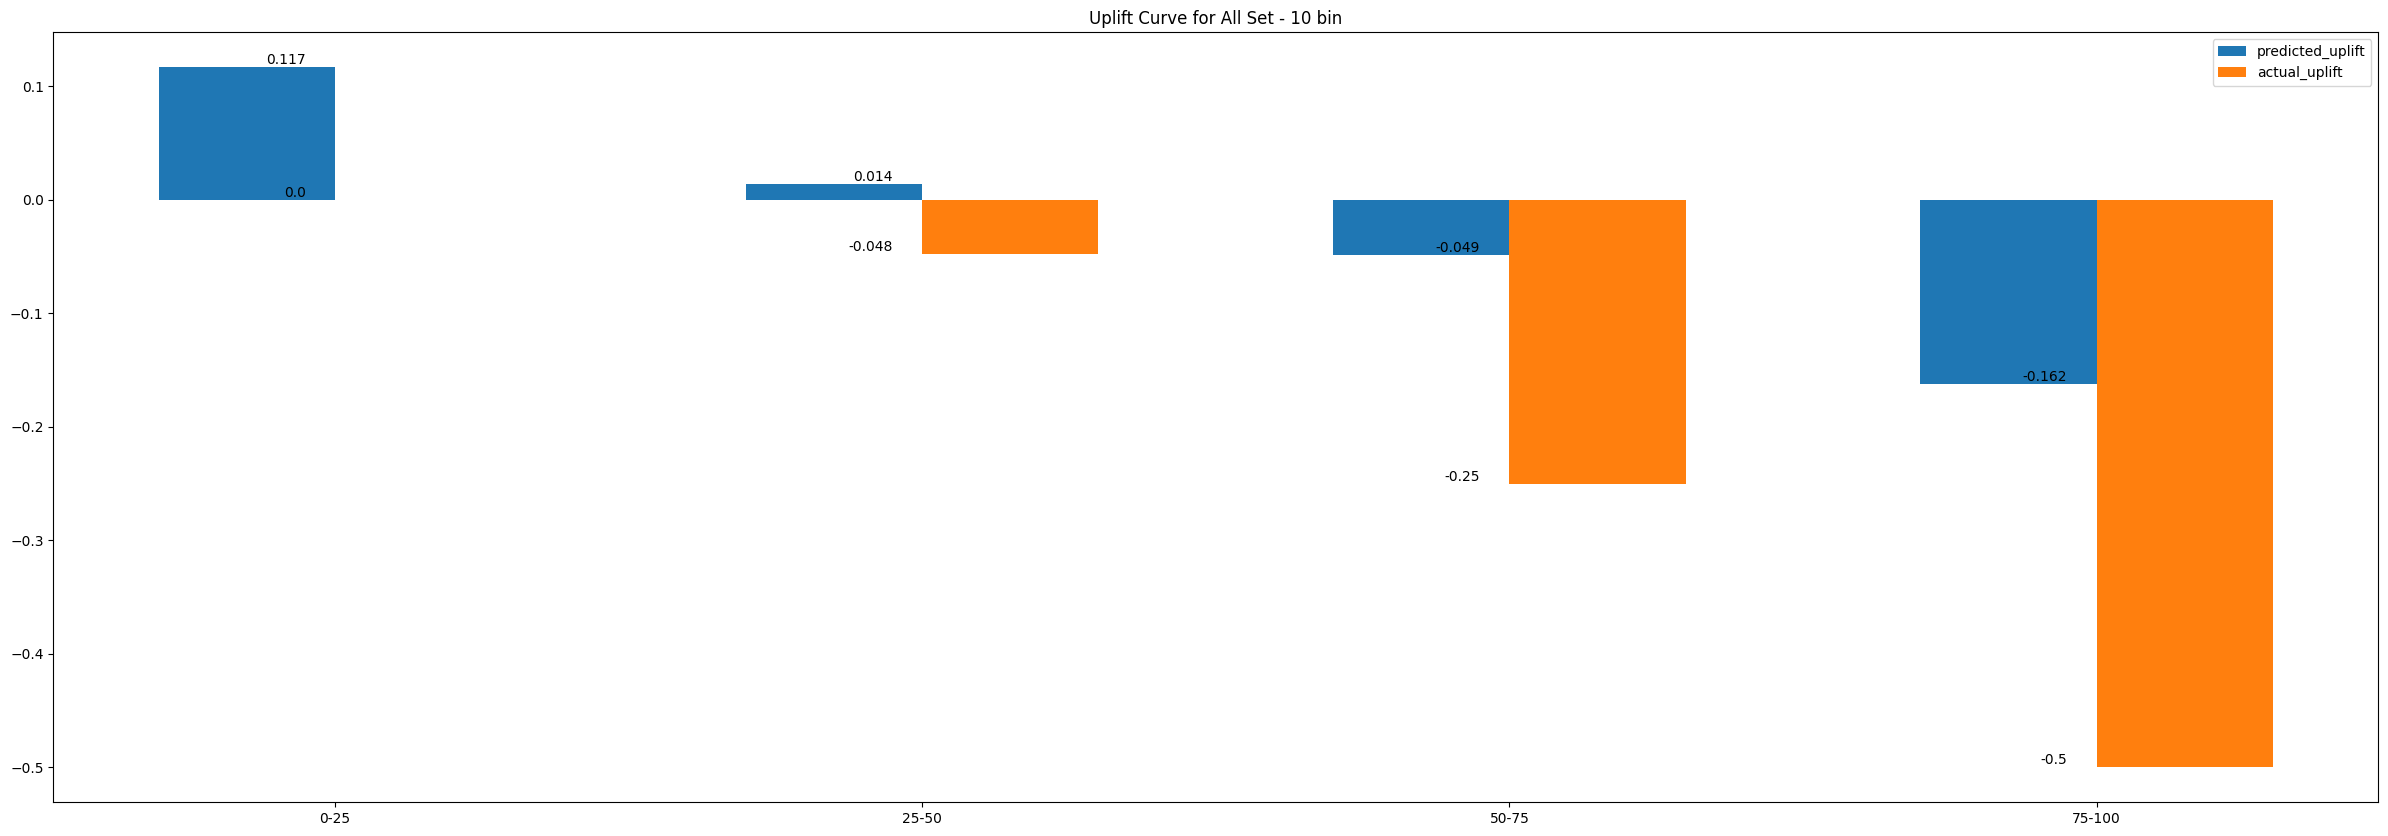

In [28]:
import matplotlib.pyplot as plt
df_bin = uplift_by_deciles(final['pod24'], final['uplift'], final['Rweichi'], bins=4)
df_bin

plt.figure(figsize=[30, 10])
bar_width=0.3
x = np.arange(4)

tick_label = df_bin['percentile']
plt.bar(x, df_bin['predicted_uplift_scores'], bar_width, label='predicted_uplift')
for a, b in enumerate(df_bin['predicted_uplift_scores'].values):
    plt.text(a+0.1, b, round(float(b), 3), ha='right', va='bottom')
plt.bar(x + bar_width, df_bin['actual_uplift_scores'], bar_width, label='actual_uplift')
for a, b in enumerate(df_bin['actual_uplift_scores'].values):
    plt.text(a+0.1, b, round(float(b), 3), ha='right', va='bottom')  

plt.legend()
plt.xticks(x+bar_width/2, tick_label)
plt.title('Uplift Curve for All Set - 10 bin')
plt.show()

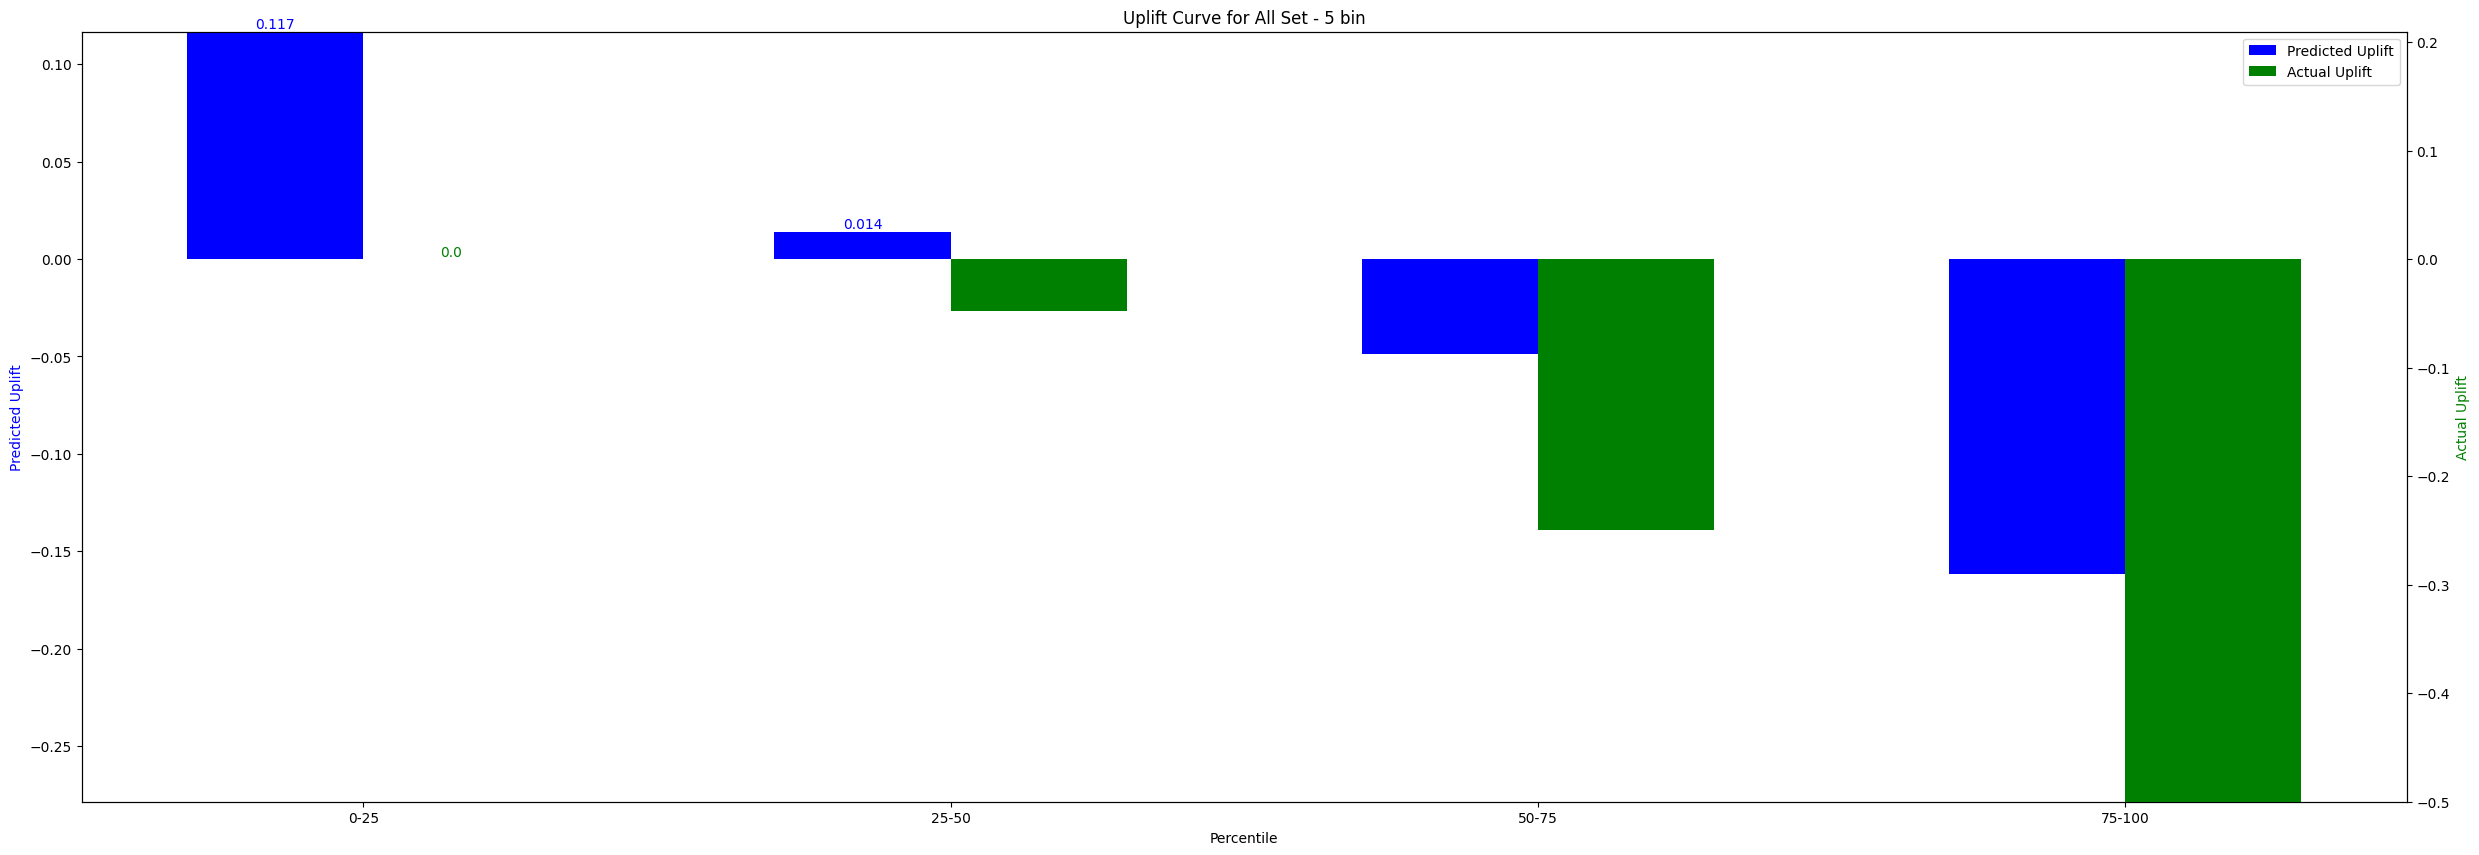

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 假设 uplift_by_deciles 函数和数据 df_bin 已经定义
df_bin = uplift_by_deciles(final['pod24'], final['uplift'], final['Rweichi'], bins=4)

fig, ax1 = plt.subplots(figsize=[30, 10])
bar_width = 0.3
x = np.arange(4)

tick_label = df_bin['percentile']

# 绘制第一个柱状图，使用左侧y轴
predicted_uplift = df_bin['predicted_uplift_scores']
actual_uplift = df_bin['actual_uplift_scores']

ax1.bar(x, predicted_uplift, bar_width, label='Predicted Uplift', color='b')
for a, b in enumerate(predicted_uplift.values):
    ax1.text(a, b, round(float(b), 3), ha='center', va='bottom', color='b')

# 创建第二个y轴，分享相同的x轴
ax2 = ax1.twinx()
ax2.bar(x + bar_width, actual_uplift, bar_width, label='Actual Uplift', color='g')
for a, b in enumerate(actual_uplift.values):
    ax2.text(a + bar_width, b, round(float(b), 3), ha='center', va='bottom', color='g')

# 设置y轴范围，以使0值对齐
max_predicted = max(predicted_uplift)
min_predicted = min(predicted_uplift)
max_actual = max(actual_uplift)
min_actual = min(actual_uplift)

# 找到两个y轴的比例
ratio = (max_predicted - min_predicted) / (max_actual - min_actual)

# 设置y轴范围
ax1.set_ylim(min(min_predicted, min_actual * ratio), max(max_predicted, max_actual * ratio))
ax2.set_ylim(min(min_actual, min_predicted / ratio), max(max_actual, max_predicted / ratio))

# 设置标签和标题
ax1.set_xlabel('Percentile')
ax1.set_ylabel('Predicted Uplift', color='b')
ax2.set_ylabel('Actual Uplift', color='g')

# 设置x轴刻度标签
plt.xticks(x + bar_width / 2, tick_label)

# 设置图例
fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)

plt.title('Uplift Curve for All Set - 5 bin')
plt.show()


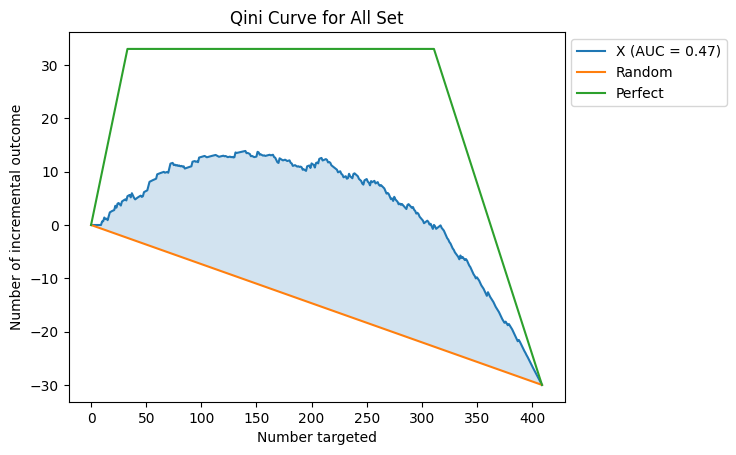

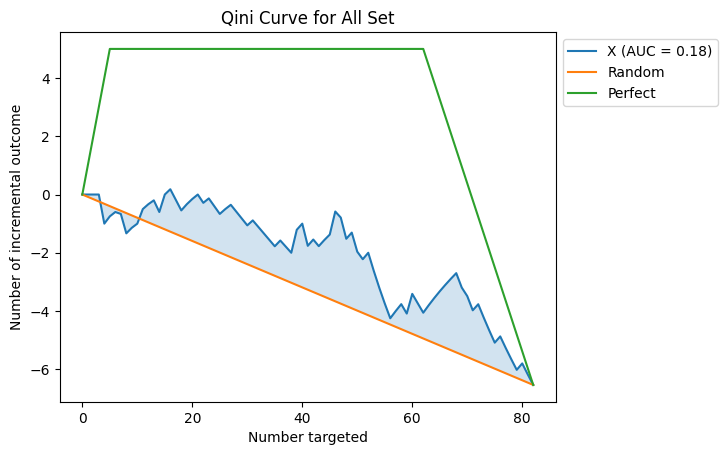

In [30]:
get_qini_curves(df_filtered['pod24'], DML.predict(df_filtered), df_filtered['Rweichi'])
get_qini_curves(final['pod24'], final['uplift'], final['Rweichi'])

In [31]:
# 计算auuc
def compute_auuc(data, label_col="order_label", treat_col="treatment", uplift_col="uplift_score", treatment_asset=1, control_asset=0):
    result = pd.DataFrame(np.c_[data[label_col], data[treat_col], data[uplift_col]], columns=['cv_flg', 'treat_flg', 'uplift_score'])
    result = result.sort_values(by='uplift_score', ascending=False).reset_index(drop=True)
    result['treat_num_cumsum'] = (result['treat_flg']==treatment_asset).cumsum()
    result['control_num_cumsum'] = (result['treat_flg']==control_asset).cumsum()
    result['treat_cv_cumsum'] = ((result['treat_flg']==treatment_asset) * result['cv_flg']).cumsum()
    result['control_cv_cumsum'] = ((result['treat_flg']==control_asset) * result['cv_flg']).cumsum()
    result['treat_cv_cumsum'] = result['treat_cv_cumsum'].astype(float)
    result['control_cv_cumsum'] = result['control_cv_cumsum'].astype(float)
    result['treat_cvr'] = (result['treat_cv_cumsum'] / result['treat_num_cumsum']).fillna(0)
    result['control_cvr'] = (result['control_cv_cumsum'] / result['control_num_cumsum']).fillna(0)
    result['lift'] = (result['treat_cvr'] - result['control_cvr']) * result['treat_num_cumsum'] # 模型累积增益
    result['base_line'] = result.index * result['lift'][len(result.index) - 1] / len(result.index) # 随机累积增益
    auuc = result['lift'].sum() / (len(result['lift']) * np.abs(result['lift'].iloc[-1])) # 归一化
    total_gain = result['lift'].iloc[-1]
    if total_gain < 0:
        auuc += 1
    return auuc

new_data = pd.DataFrame({
    'label_col': df_filtered['pod24'].values,  # 将 'pod24' 列赋值给 'label_col'
    'uplift_col': DML.predict(df_filtered),  # 将 'Rweichi' 列赋值给 'uplift_col'
    'treat_col': df_filtered['Rweichi'].values
})
auuc = compute_auuc(new_data, label_col="label_col", treat_col="treat_col", uplift_col="uplift_col", treatment_asset=1, control_asset=0)
print(f'all set auuc = {auuc:.6f}')

new_data_test = pd.DataFrame({
    'label_col': final['pod24'].values,  # 将 'pod24' 列赋值给 'label_col'
    'uplift_col': final['uplift'],  # 将 'Rweichi' 列赋值给 'uplift_col'
    'treat_col': final['Rweichi'].values
})
auuc = compute_auuc(new_data_test, label_col="label_col", treat_col="treat_col", uplift_col="uplift_col", treatment_asset=1, control_asset=0)
print(f'testing set auuc = {auuc:.6f}')

all set auuc = 1.111356
testing set auuc = 0.679915


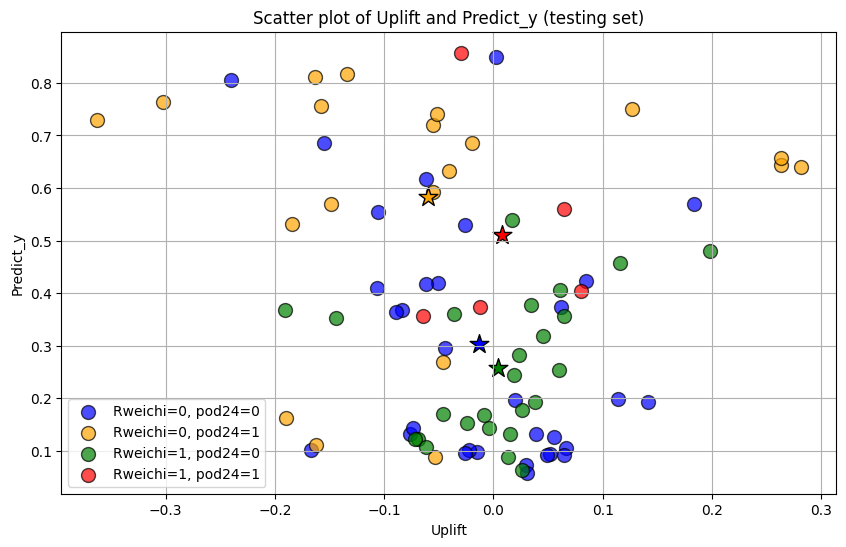

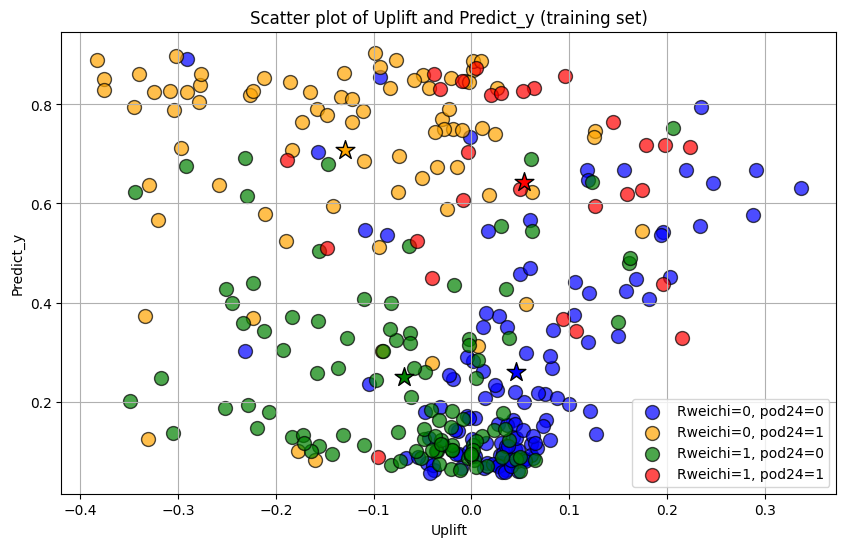

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

for j in range(2):
    if j == 0:
        # 测试集散点图绘图
        # 1. 数据准备
        X = final[['uplift', 'predict_y']]  # 特征
        y = final[['Rweichi', 'pod24']]  # 标签
        dataset_name = 'testing set'

    else:
        X = final_train[['uplift', 'predict_y']]  # 特征
        y = final_train[['Rweichi', 'pod24']]  # 标签
        dataset_name = 'training set'
    # 2. 特征构造：将标签合并为一个四分类标签
    y_combined = (y['Rweichi'] * 2 + y['pod24']).astype('int')  # 0, 1, 2, 3 四个类别
    
    # 3. 拆分数据集
    #X_train, X_test, y_train, y_test = train_test_split(X, y_combined, test_size=0.2, random_state=42)
    
    # 4. 模型选择：使用随机森林分类器
    #model = RandomForestClassifier(random_state=42)
    
    # 5. 模型训练
    #model.fit(X_train, y_train)
    
    # 6. 模型预测
    #y_pred = model.predict(X_test)
    
    # 7. 绘制散点图
    plt.figure(figsize=(10, 6))
    
    # 8. 绘制每个分类的散点图
    colors = ['blue', 'orange', 'green', 'red']
    labels = ['Rweichi=0, pod24=0', 'Rweichi=0, pod24=1', 'Rweichi=1, pod24=0', 'Rweichi=1, pod24=1']
    
    for i in range(4):
        plt.scatter(X[y_combined == i]['uplift'], X[y_combined == i]['predict_y'], 
                    color=colors[i], label=labels[i], edgecolor='k', s=100, alpha=0.7)
        plt.scatter(np.mean(X[y_combined == i]['uplift']), np.mean(X[y_combined == i]['predict_y']),
                    color=colors[i], marker='*', edgecolor='k', s=200)
    
    # 9. 添加图例
    plt.legend()
    
    # 10. 添加标题和标签
    plt.title('Scatter plot of Uplift and Predict_y' + ' (' + dataset_name + ')')
    plt.xlabel('Uplift')
    plt.ylabel('Predict_y')
    plt.grid(True)
    
    # 11. 显示图形
    plt.savefig(f'{j}.png')
    plt.show()



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


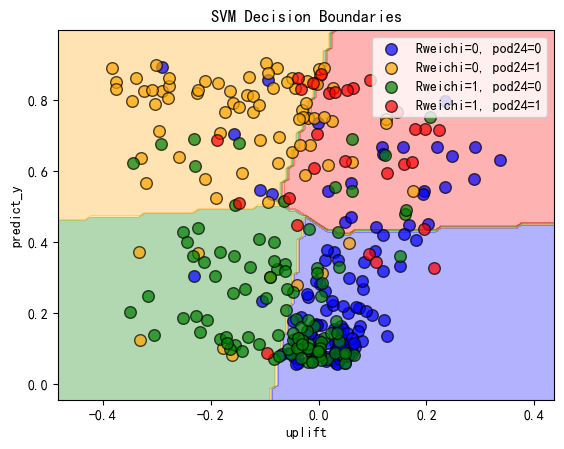

整体准确率: 0.38
区域0准确率：0.44
区域1准确率：0.64
区域2准确率：0.27
区域3准确率：0.07
——————————对黄色、绿色、红色部分都进行推荐——————————
——————————因果推断推荐模型——————————
——————————测试集——————————
[2 2 3 0 1 0 2 1 0 0 0 0 1 0 3 0 0 0 0 0 3 1 1 1 3 2 2 1 0 0 0 2 2 0 3 1 1
 3 0 0 2 3 1 0 1 0 0 0 2 0 0 2 0 0 0 0 2 0 1 0 0 2 0 1 2 0 3 0 3 0 3 0 3 0
 0 2 2 1 3 0 3 3]
       uplift  predict_y
263 -0.064902   0.356838
363 -0.189487   0.162077
76   0.064395   0.560107
254  0.079691   0.404566
26  -0.061592   0.617925
..        ...        ...
288 -0.184003   0.532423
97   0.127150   0.749918
349 -0.062009   0.107139
316 -0.019686   0.686080
51   0.001955   0.849060

[82 rows x 2 columns]
实际与推荐一致的样本数:29,进展率:0.1724137931034483
实际与推荐不一致的样本数:53,进展率:0.37735849056603776
——————————训练集——————————
实际与推荐一致的样本数:174,进展率:0.16091954022988506
实际与推荐不一致的样本数:153,进展率:0.5098039215686274
——————————医生诊断模型——————————
实际与推荐一致的样本数:44,进展率:0.22727272727272727
实际与推荐不一致的样本数:34,进展率:0.3235294117647059
category2
0    17
1     5
2     8
3     0
4    15
5    11
6    17
7     

C:\Users\Tilofy\AppData\Local\Temp\ipykernel_19220\969889318.py:161: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final['recommendation1'] = recommendation
C:\Users\Tilofy\AppData\Local\Temp\ipykernel_19220\969889318.py:162: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final['category'] = final.apply(lambda row: row['recommendation1'] * 4 + row['Rweichi'] * 2 + row['pod24'], axis=1)


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import svm
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from joblib import load
import matplotlib.font_manager as fm

# 设置字体为SimHei (黑体)，确保支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决坐标轴负号显示问题

# Generate some synthetic data for illustration
# This creates 4 classes with 2 features
X = final_train[['uplift', 'predict_y']]  # 特征
y_origin = final_train[['Rweichi', 'pod24']]  # 标签
y_combined = (y_origin['Rweichi'] * 2 + y_origin['pod24']).astype('int')

# Fit an SVM model
model = svm.SVC(kernel='rbf', C=1, class_weight='balanced', gamma=0.5)  # Use the RBF kernel for non-linear boundaries
model.fit(X, y_combined)

# Define a mesh grid to plot the decision boundaries
x1_min, x1_max = X['uplift'].min() - 0.1, X['uplift'].max() + 0.1
x2_min, x2_max = X['predict_y'].min() - 0.1, X['predict_y'].max() + 0.1
xx, yy = np.meshgrid(np.arange(x1_min, x1_max, 0.01),
                     np.arange(x2_min, x2_max, 0.01))

# Predict on the mesh grid to create the decision boundary
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting the decision boundaries
cmap = ListedColormap(['blue', 'orange', 'green', 'red'])
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
colors = ['blue', 'orange', 'green', 'red']
labels = ['Rweichi=0, pod24=0', 'Rweichi=0, pod24=1', 'Rweichi=1, pod24=0', 'Rweichi=1, pod24=1']
for i in range(4):
    plt.scatter(X[y_combined == i]['uplift'], X[y_combined == i]['predict_y'], 
                color=colors[i], label=labels[i], edgecolor='k', s=70, alpha=0.7)
#X = final[['uplift', 'predict_y']]
#y_origin = final[['Rweichi', 'pod24']]
#y_combined = (y_origin['Rweichi'] * 2 + y_origin['pod24']).astype('int')
#for i in range(4):
#    plt.scatter(X[y_combined == i]['uplift'], X[y_combined == i]['predict_y'], 
#                color=colors[i], label=labels[i], edgecolor='k', s=70, alpha=0.7)
plt.xlabel('uplift')
plt.ylabel('predict_y')
plt.title('SVM Decision Boundaries')
plt.legend()
plt.savefig('huafen.png')
plt.show()

X_test = final[['uplift', 'predict_y']]  # 特征
Y_test = final[['Rweichi', 'pod24']]  # 标签
y = (Y_test['Rweichi'] * 2 + Y_test['pod24']).astype('int')
y_pred = model.predict(X_test)
overall_accuracy = accuracy_score(y,y_pred)
print(f'整体准确率: {overall_accuracy:.2f}')

for i in range(4):
    indices = np.where(y_pred == i)[0]
    corresponding_values = y.iloc[indices]

    # 计算对应位置中为 i 的数量
    num_i = np.sum(corresponding_values == i)

    # 计算为 i 的比例
    proportion = num_i / len(indices) if len(indices) > 0 else 0
    print(f'区域{i}准确率：{proportion:.2f}')
'''
#只推荐黄色部分的策略:
print('——————————只对黄色部分进行推荐——————————')
print('——————————测试集——————————')
y_pred = model.predict(X_test)
recommendation = np.where(y_pred == 1, 1, 0)
final['recommendation'] = recommendation
final['category'] = final.apply(lambda row: row['recommendation'] * 4 + row['Rweichi'] * 2 + row['pod24'], axis=1)
valuecounts_unindexed = final['category'].value_counts().sort_index()

full_range = range(8)
valuecounts = valuecounts_unindexed.reindex(full_range, fill_value=0)

consis_y_prob = (valuecounts[7] + valuecounts[1]) / (valuecounts[7] + valuecounts[1] + valuecounts[6] + valuecounts[0])
unconsis_y_prob = (valuecounts[3] + valuecounts[5]) / (valuecounts[3] + valuecounts[5] + valuecounts[2] + valuecounts[4])
print(f'实际与推荐一致的样本数:{valuecounts[7]+valuecounts[1]+valuecounts[6]+valuecounts[0]},进展率:{consis_y_prob}')
print(f'实际与推荐不一致的样本数:{valuecounts[3]+valuecounts[5]+valuecounts[2]+valuecounts[4]},进展率:{unconsis_y_prob}')

print('——————————训练集——————————')
X_train = final_train[['uplift', 'predict_y']]
y_pred2 = model.predict(X_train)
recommendation = np.where(y_pred2 == 1, 1, 0)
final_train['recommendation'] = recommendation
final_train['category'] = final_train.apply(lambda row: row['recommendation'] * 4 + row['Rweichi'] * 2 + row['pod24'], axis=1)
valuecounts_unindexed = final_train['category'].value_counts().sort_index()

full_range = range(8)
valuecounts = valuecounts_unindexed.reindex(full_range, fill_value=0)

consis_y_prob = (valuecounts[7] + valuecounts[1]) / (valuecounts[7] + valuecounts[1] + valuecounts[6] + valuecounts[0])
unconsis_y_prob = (valuecounts[3] + valuecounts[5]) / (valuecounts[3] + valuecounts[5] + valuecounts[2] + valuecounts[4])
print(f'实际与推荐一致的样本数:{valuecounts[7]+valuecounts[1]+valuecounts[6]+valuecounts[0]},进展率:{consis_y_prob}')
print(f'实际与推荐不一致的样本数:{valuecounts[3]+valuecounts[5]+valuecounts[2]+valuecounts[4]},进展率:{unconsis_y_prob}')
'''
print('——————————对黄色、绿色、红色部分都进行推荐——————————')
print('——————————因果推断推荐模型——————————')
print('——————————测试集——————————')
y_pred = model.predict(X_test)

print(y_pred)
print(X_test)

recommendation = np.where(y_pred != 0, 1, 0)
final['recommendation'] = recommendation
final['category'] = final.apply(lambda row: row['recommendation'] * 4 + row['Rweichi'] * 2 + row['pod24'], axis=1)
valuecounts_unindexed = final['category'].value_counts().sort_index()

full_range = range(8)
valuecounts = valuecounts_unindexed.reindex(full_range, fill_value=0)

consis_y_prob = (valuecounts[7] + valuecounts[1]) / (valuecounts[7] + valuecounts[1] + valuecounts[6] + valuecounts[0])
unconsis_y_prob = (valuecounts[3] + valuecounts[5]) / (valuecounts[3] + valuecounts[5] + valuecounts[2] + valuecounts[4])
print(f'实际与推荐一致的样本数:{valuecounts[7]+valuecounts[1]+valuecounts[6]+valuecounts[0]},进展率:{consis_y_prob}')
print(f'实际与推荐不一致的样本数:{valuecounts[3]+valuecounts[5]+valuecounts[2]+valuecounts[4]},进展率:{unconsis_y_prob}')

print('——————————训练集——————————')
X_train = final_train[['uplift', 'predict_y']]
y_pred2 = model.predict(X_train)
recommendation = np.where(y_pred2 != 0, 1, 0)
final_train['recommendation'] = recommendation
final_train['category'] = final_train.apply(lambda row: row['recommendation'] * 4 + row['Rweichi'] * 2 + row['pod24'], axis=1)
valuecounts_unindexed = final_train['category'].value_counts().sort_index()

full_range = range(8)
valuecounts = valuecounts_unindexed.reindex(full_range, fill_value=0)

consis_y_prob_train = (valuecounts[7] + valuecounts[1]) / (valuecounts[7] + valuecounts[1] + valuecounts[6] + valuecounts[0])
unconsis_y_prob_train = (valuecounts[3] + valuecounts[5]) / (valuecounts[3] + valuecounts[5] + valuecounts[2] + valuecounts[4])
print(f'实际与推荐一致的样本数:{valuecounts[7]+valuecounts[1]+valuecounts[6]+valuecounts[0]},进展率:{consis_y_prob_train}')
print(f'实际与推荐不一致的样本数:{valuecounts[3]+valuecounts[5]+valuecounts[2]+valuecounts[4]},进展率:{unconsis_y_prob_train}')


print('——————————医生诊断模型——————————')
final['category2'] = final.apply(lambda row: row['治疗前是否高肿瘤负荷（受累淋巴结>=3个，直径>=3cm；任何淋巴结或者结外瘤块直径>=7cm；B症状；脾大；胸腔积液、腹水；白细胞<1.0*109/L和/或血小板<100*109/L；白血病期）'] * 4 + row['Rweichi'] * 2 + row['pod24'], axis=1)
final = final.dropna(subset=['治疗前是否高肿瘤负荷（受累淋巴结>=3个，直径>=3cm；任何淋巴结或者结外瘤块直径>=7cm；B症状；脾大；胸腔积液、腹水；白细胞<1.0*109/L和/或血小板<100*109/L；白血病期）'])

valuecounts_unindexed = final['category2'].value_counts().sort_index()

full_range = range(8)
valuecounts = valuecounts_unindexed.reindex(full_range, fill_value=0)
consis_y_prob = (valuecounts[7] + valuecounts[1]) / (valuecounts[7] + valuecounts[1] + valuecounts[6] + valuecounts[0])
unconsis_y_prob = (valuecounts[3] + valuecounts[5]) / (valuecounts[3] + valuecounts[5] + valuecounts[2] + valuecounts[4])
print(f'实际与推荐一致的样本数:{valuecounts[7]+valuecounts[1]+valuecounts[6]+valuecounts[0]},进展率:{consis_y_prob}')
print(f'实际与推荐不一致的样本数:{valuecounts[3]+valuecounts[5]+valuecounts[2]+valuecounts[4]},进展率:{unconsis_y_prob}')
print(valuecounts)

X_test = final[['uplift', 'predict_y']]  # 特征
y_pred = model.predict(X_test)
recommendation = np.where(y_pred != 0, 1, 0)
final['recommendation1'] = recommendation
final['category'] = final.apply(lambda row: row['recommendation1'] * 4 + row['Rweichi'] * 2 + row['pod24'], axis=1)
valuecounts_unindexed = final['category'].value_counts().sort_index()

full_range = range(8)
valuecounts = valuecounts_unindexed.reindex(full_range, fill_value=0)

consis_y_prob = (valuecounts[7] + valuecounts[1]) / (valuecounts[7] + valuecounts[1] + valuecounts[6] + valuecounts[0])
unconsis_y_prob = (valuecounts[3] + valuecounts[5]) / (valuecounts[3] + valuecounts[5] + valuecounts[2] + valuecounts[4])
print(f'实际与推荐一致的样本数:{valuecounts[7]+valuecounts[1]+valuecounts[6]+valuecounts[0]},进展率:{consis_y_prob}')
print(f'实际与推荐不一致的样本数:{valuecounts[3]+valuecounts[5]+valuecounts[2]+valuecounts[4]},进展率:{unconsis_y_prob}')
print(valuecounts)



In [34]:
print(type(X_test)) 
print(X_test.shape)

<class 'pandas.core.frame.DataFrame'>
(78, 2)


In [35]:
# 专家模型
professor_data = df[['治疗时FLIPI-1（最终版）', '治疗FLIPI2（最终版）', '一线治疗时PRIMA-PI', '一线PFS(确诊时间-进展时间，需要写函数)', '治疗前是否高肿瘤负荷（受累淋巴结>=3个，直径>=3cm；任何淋巴结或者结外瘤块直径>=7cm；B症状；脾大；胸腔积液、腹水；白细胞<1.0*109/L和/或血小板<100*109/L；白血病期）', '一线后是否进展', '是否POD24(0=无，1=是,2=非免疫化疗，3=随访<24个月，4=NA)', 'R维持分类（0:无；1:有；2:NA;3:非免疫）']]
data = professor_data.copy(deep=True)
df_filtered_prof = data[data['治疗前是否高肿瘤负荷（受累淋巴结>=3个，直径>=3cm；任何淋巴结或者结外瘤块直径>=7cm；B症状；脾大；胸腔积液、腹水；白细胞<1.0*109/L和/或血小板<100*109/L；白血病期）'].isin([0, 1])]
condition = (df_filtered_prof['一线PFS(确诊时间-进展时间，需要写函数)'] < 24) & (df_filtered_prof['一线后是否进展'] == 0)
df_filtered_prof = df_filtered_prof[~condition]
df_filtered_prof = df_filtered_prof[df_filtered_prof['是否POD24(0=无，1=是,2=非免疫化疗，3=随访<24个月，4=NA)'].isin([0, 1])]
df_filtered_prof = df_filtered_prof[df_filtered_prof['R维持分类（0:无；1:有；2:NA;3:非免疫）'].isin([0, 1])]
df_filtered_prof.rename(columns={'治疗前是否高肿瘤负荷（受累淋巴结>=3个，直径>=3cm；任何淋巴结或者结外瘤块直径>=7cm；B症状；脾大；胸腔积液、腹水；白细胞<1.0*109/L和/或血小板<100*109/L；白血病期）': 'Rweichi', '是否POD24(0=无，1=是,2=非免疫化疗，3=随访<24个月，4=NA)': 'pod24'}, inplace=True)
'''
df_train_prof, df_test_prof = train_test_split(df_filtered_prof, test_size=0.2, random_state=16)
X_train = df_train_prof[['治疗时FLIPI-1（最终版）', '治疗FLIPI2（最终版）', '一线治疗时PRIMA-PI']]
y_train = df_train_prof['Rweichi']
X_test = df_test_prof[['治疗时FLIPI-1（最终版）', '治疗FLIPI2（最终版）', '一线治疗时PRIMA-PI']]
y_test = df_test_prof['Rweichi']
model = CatBoostClassifier(iterations=100,
                              learning_rate=0.1,
                              depth=6,
                              loss_function='CrossEntropy',
                              verbose=10)
model.fit(X_train, y_train)
y_pred_prof = model.predict(X_test)
accuracy_prof = accuracy_score(y_test, y_pred_prof)
auc_value = roc_auc_score(y_test, y_pred_prof)
y_prob_prof = model.predict_proba(X_test)[:,1]
print(f"准确率: {accuracy_prof:.2f}")
print(f"AUC: {auc_value:.2f}")


recommendation = y_pred_prof
df_test_prof['recommendation'] = recommendation
'''
df_filtered_prof['category'] = df_filtered_prof.apply(lambda row: row['Rweichi'] * 4 + row['R维持分类（0:无；1:有；2:NA;3:非免疫）'] * 2 + row['pod24'], axis=1)
valuecounts_unindexed = df_filtered_prof['category'].value_counts().sort_index()
full_range = range(8)
valuecounts = valuecounts_unindexed.reindex(full_range, fill_value=0)
consis_y_prob = (valuecounts[7] + valuecounts[1]) / (valuecounts[7] + valuecounts[1] + valuecounts[6] + valuecounts[0])
unconsis_y_prob = (valuecounts[3] + valuecounts[5]) / (valuecounts[3] + valuecounts[5] + valuecounts[2] + valuecounts[4])
print(f'实际与推荐一致的样本数:{valuecounts[7]+valuecounts[1]+valuecounts[6]+valuecounts[0]},进展率:{consis_y_prob}')
print(f'实际与推荐不一致的样本数:{valuecounts[3]+valuecounts[5]+valuecounts[2]+valuecounts[4]},进展率:{unconsis_y_prob}')


Rweichi_actual = df_test_prof['R维持分类（0:无；1:有；2:NA;3:非免疫）'].values
y_actual = df_test_prof['pod24']

data = pd.DataFrame({'y_prob_prof': y_prob_prof, 'Rweichi_actual': Rweichi_actual, 'y_actual': y_actual})

# 将 y_prob_prof 按照 0.1 为间隔分组
bins = np.arange(0, 1.1, 0.1)  # 创建分组区间
labels = [f'{bins[i]:.1f}-{bins[i+1]:.1f}' for i in range(len(bins)-1)]
data['score_range'] = pd.cut(data['y_prob_prof'], bins=bins, labels=labels, include_lowest=True)

# 统计每个分组中 Rweichi_actual 和 y_actual 为 0 和 1 的数量
grouped_counts_Rweichi = data.groupby('score_range')['Rweichi_actual'].value_counts().unstack().fillna(0)
grouped_counts_y_actual = data.groupby('score_range')['y_actual'].value_counts().unstack().fillna(0)
# 绘制柱状图
fig, ax = plt.subplots(figsize=(12, 6))

# 绘制 Rweichi_actual 的柱状图
grouped_counts_Rweichi.plot(kind='bar', stacked=True, ax=ax, color=['blue', 'orange'], position=1, width=0.3)

# 绘制 y_actual 的柱状图，使用不同的颜色并调整位置
# grouped_counts_y_actual.plot(kind='bar', stacked=True, ax=ax, color=['green', 'red'], position=0, width=0.3)

plt.xlabel('Score')
plt.ylabel('Count')
plt.title('Distribution of Rweichi_actual and y_actual by Predict Probability')
plt.legend(['Rweichi_actual = 0', 'Rweichi_actual = 1', 'y_actual = 0', 'y_actual = 1'])
plt.show()


实际与推荐一致的样本数:203,进展率:0.23645320197044334
实际与推荐不一致的样本数:188,进展率:0.3776595744680851


NameError: name 'df_test_prof' is not defined

In [48]:
# 验证数据集中Rweichi标签是否合理
flipi1_count = df_filtered_prof.groupby('治疗时FLIPI-1（最终版）')['Rweichi'].value_counts().unstack(fill_value=0)

# 根据 '治疗FLIPI2（最终版）' 进行分组并计数 Rweichi
flipi2_count = df_filtered_prof.groupby('治疗FLIPI2（最终版）')['Rweichi'].value_counts().unstack(fill_value=0)

# 根据 '一线治疗时PRIMA-PI' 进行分组并计数 Rweichi
prima_pi_count = df_filtered_prof.groupby('一线治疗时PRIMA-PI')['Rweichi'].value_counts().unstack(fill_value=0)

# 输出结果
print("治疗时FLIPI-1（最终版）计数:")
print(flipi1_count)

print("\n治疗FLIPI2（最终版）计数:")
print(flipi2_count)

print("\n一线治疗时PRIMA-PI计数:")
print(prima_pi_count)

flipi1_count = df_filtered_prof.groupby('治疗时FLIPI-1（最终版）')['pod24'].value_counts().unstack(fill_value=0)

# 根据 '治疗FLIPI2（最终版）' 进行分组并计数 Rweichi
flipi2_count = df_filtered_prof.groupby('治疗FLIPI2（最终版）')['pod24'].value_counts().unstack(fill_value=0)

# 根据 '一线治疗时PRIMA-PI' 进行分组并计数 Rweichi
prima_pi_count = df_filtered_prof.groupby('一线治疗时PRIMA-PI')['pod24'].value_counts().unstack(fill_value=0)

# 输出结果
print("治疗时FLIPI-1（最终版）计数:")
print(flipi1_count)

print("\n治疗FLIPI2（最终版）计数:")
print(flipi2_count)

print("\n一线治疗时PRIMA-PI计数:")
print(prima_pi_count)

治疗时FLIPI-1（最终版）计数:
Rweichi          0.0  1.0
治疗时FLIPI-1（最终版）          
0.0               28   11
1.0               27   11
2.0               47  101
3.0               26   82
4.0                7   31
5.0                3   10

治疗FLIPI2（最终版）计数:
Rweichi        0.0  1.0
治疗FLIPI2（最终版）          
0.0             66   20
1.0             40   55
2.0             21   89
3.0              9   56
4.0              2   22
5.0              0    4

一线治疗时PRIMA-PI计数:
Rweichi        0.0  1.0
一线治疗时PRIMA-PI          
0.0             88   66
1.0             32   73
2.0             18  109
治疗时FLIPI-1（最终版）计数:
pod24              0   1
治疗时FLIPI-1（最终版）         
0.0               34   5
1.0               37   1
2.0              122  26
3.0               57  51
4.0               14  24
5.0                6   7

治疗FLIPI2（最终版）计数:
pod24           0   1
治疗FLIPI2（最终版）        
0.0            81   5
1.0            85  10
2.0            66  44
3.0            28  37
4.0             8  16
5.0             2   2

一线治疗时PRIMA-

In [50]:
auroc = roc_auc_score(final['pod24'], final['predict_y'])
print(f'AUROC: {auroc}')

AUROC: 0.7919799498746867


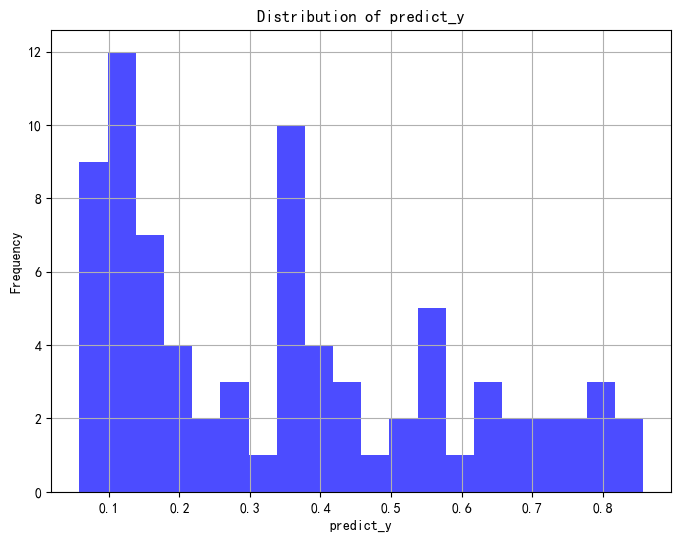

In [69]:

import pickle

plt.figure(figsize=(8, 6))
plt.hist(final['predict_y'], bins=20, color='blue', alpha=0.7)
plt.title('Distribution of predict_y')
plt.xlabel('predict_y')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


with open('predict_y.pkl', 'wb') as file:
    pickle.dump(final['predict_y'], file)
with open('uplift.pkl', 'wb') as file:
    pickle.dump(final['uplift'], file)


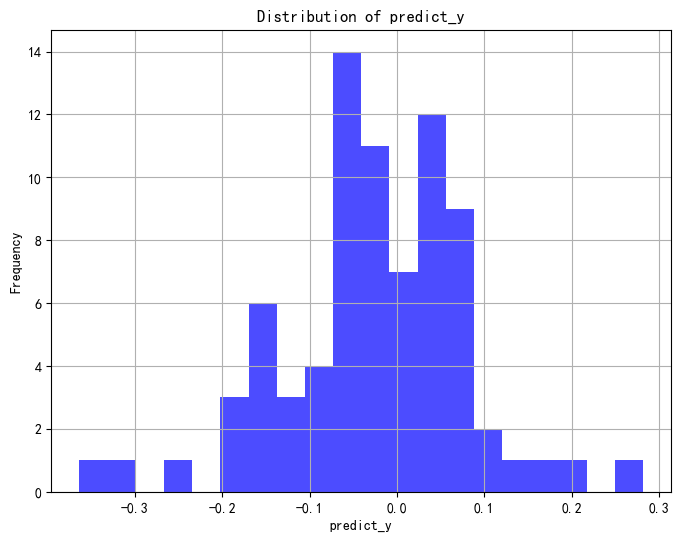

In [67]:
plt.figure(figsize=(8, 6))
plt.hist(final['uplift'], bins=20, color='blue', alpha=0.7)
plt.title('Distribution of predict_y')
plt.xlabel('predict_y')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [54]:
print(np.mean(DML.predict(df_train)))
print(np.mean(DML.predict(df_test)))
print(np.mean(DML.predict(df_filtered)))

-0.03561363950760226
-0.013679688026549449
-0.02852239263629901


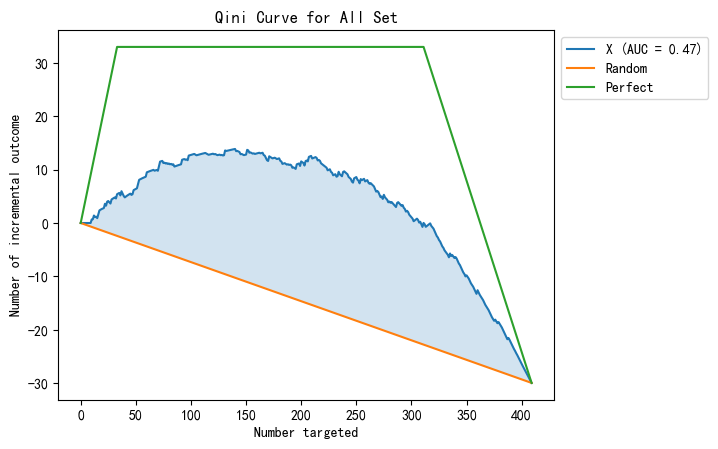

In [56]:
get_qini_curves(df_filtered['pod24'], DML.predict(df_filtered), df_filtered['Rweichi'])

In [58]:
DML.get_feature_importance()

,feature,importance
14,LDH（首次治疗）>240是预后不良因素,13.824158
8,评效分组1,13.652311
15,β2微球蛋白β2-MG（首次治疗）>3是预后不良因素,9.490761
13,一线治疗时累及淋巴结区数目（大于等于5预后不良）,8.973060
18,PLT（首次治疗）,6.493082
11,SUVmax（首次治疗）,6.147147
19,单核细胞绝对值（首次治疗）,6.104101
0,性别（0:女；1:男）,5.703825
9,启动一线治疗原因（新补充）,5.105244
10,最大病灶cm（首次治疗）,4.738566


——————————测试集——————————


C:\Users\Tilofy\AppData\Local\Temp\ipykernel_19220\3379005278.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final['recommendation'] = recommendation
C:\Users\Tilofy\AppData\Local\Temp\ipykernel_19220\3379005278.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final['category'] = final.apply(lambda row: row['recommendation'] * 4 + row['Rweichi'] * 2 + row['pod24'], axis=1)


——————————训练集——————————


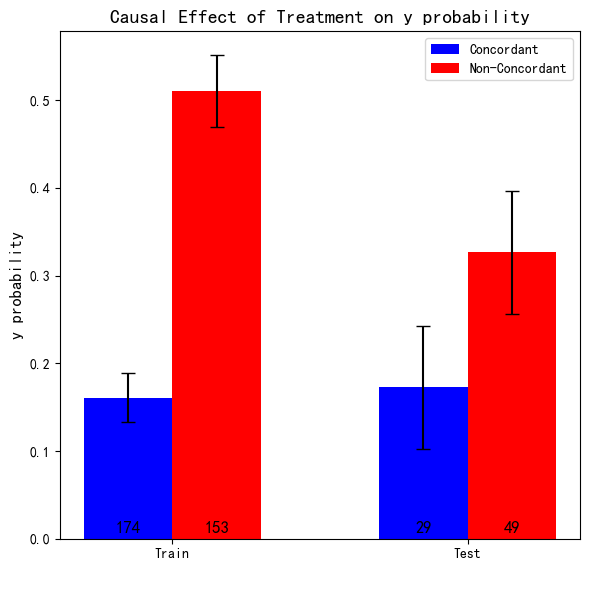

In [60]:
def bootstrap_stat(df, n_iterations=1000):
    concordant_samples = []
    nonconcordant_samples = []
    
    for i in range(n_iterations):
        # 从原始数据中有放回地进行采样
        boot_sample = df.sample(frac=1, replace=True)
        category_counts = boot_sample['category'].value_counts().reindex(range(8), fill_value=0)
        
        # 计算每次Bootstrap样本的concordant_y_test和nonconcordant_y_test
        concordant_y = (category_counts[7] + category_counts[1]) / (category_counts[7] + category_counts[1] + category_counts[6] + category_counts[0])
        nonconcordant_y = (category_counts[5] + category_counts[3]) / (category_counts[5] + category_counts[3] + category_counts[4] + category_counts[2])
        
        concordant_samples.append(concordant_y)
        nonconcordant_samples.append(nonconcordant_y)
    
    # 计算误差条 (标准差 或者 95%置信区间)
    concordant_y_test_error = np.std(concordant_samples)
    nonconcordant_y_test_error = np.std(nonconcordant_samples)
    
    # 如果需要计算置信区间，可以使用np.percentile:
    concordant_y_test_CI = np.percentile(concordant_samples, [2.5, 97.5])
    nonconcordant_y_test_CI = np.percentile(nonconcordant_samples, [2.5, 97.5])
    
    return concordant_y_test_error, nonconcordant_y_test_error, concordant_y_test_CI, nonconcordant_y_test_CI
    
print('——————————测试集——————————')
y_pred = model.predict(X_test)
recommendation = np.where(y_pred != 0, 1, 0)
final['recommendation'] = recommendation
final['category'] = final.apply(lambda row: row['recommendation'] * 4 + row['Rweichi'] * 2 + row['pod24'], axis=1)
valuecounts_unindexed = final['category'].value_counts().sort_index()

full_range = range(8)
valuecounts = valuecounts_unindexed.reindex(full_range, fill_value=0)


concordant_count_test = valuecounts[7]+valuecounts[1]+valuecounts[6]+valuecounts[0]
nonconcordant_count_test = valuecounts[3]+valuecounts[5]+valuecounts[2]+valuecounts[4]

concordant_y_test = (valuecounts[7] + valuecounts[1]) / concordant_count_test
nonconcordant_y_test = (valuecounts[5] + valuecounts[3]) / nonconcordant_count_test


# 调用bootstrap函数，设定抽样1000次
concordant_error_test, nonconcordant_error_test, concordant_CI_test, nonconcordant_CI_test = bootstrap_stat(final)

print('——————————训练集——————————')
X_train = final_train[['uplift', 'predict_y']]
y_pred2 = model.predict(X_train)
recommendation = np.where(y_pred2 != 0, 1, 0)
final_train['recommendation'] = recommendation
final_train['category'] = final_train.apply(lambda row: row['recommendation'] * 4 + row['Rweichi'] * 2 + row['pod24'], axis=1)
valuecounts_unindexed = final_train['category'].value_counts().sort_index()

full_range = range(8)
valuecounts = valuecounts_unindexed.reindex(full_range, fill_value=0)

concordant_count_train = valuecounts[7]+valuecounts[1]+valuecounts[6]+valuecounts[0]
nonconcordant_count_train = valuecounts[3]+valuecounts[5]+valuecounts[2]+valuecounts[4]

concordant_y_train = (valuecounts[7] + valuecounts[1]) / concordant_count_train
nonconcordant_y_train = (valuecounts[5] + valuecounts[3]) / nonconcordant_count_train

concordant_error_train, nonconcordant_error_train, concordant_CI_train, nonconcordant_CI_train = bootstrap_stat(final_train)


# 样本数据
categories = ['Train', 'Test']
y_concordant = [concordant_y_train, concordant_y_test]
y_nonconcordant = [nonconcordant_y_train, nonconcordant_y_test]
conf_intervals_concordant = [concordant_error_train, concordant_error_test]  # 一致组的误差条
conf_intervals_non_concordant = [nonconcordant_error_train, nonconcordant_error_test]  # 非一致组的误差条
sample_sizes_concordant = [concordant_count_train, concordant_count_test]  # 一致组样本数
sample_sizes_non_concordant = [nonconcordant_count_train, nonconcordant_count_test]  # 非一致组样本数

# ATE数据
ate_values = [concordant_y_train-nonconcordant_y_train, concordant_y_test-nonconcordant_y_test]  # 统计显著的ATE值
ate_errors = [concordant_error_train+nonconcordant_error_train, concordant_error_test+nonconcordant_error_test]  # ATE的误差条

# 设置图像
fig, ax = plt.subplots(figsize=(6, 6))

# 定义柱状图的X轴位置
x = np.arange(len(categories))

# 宽度设置
bar_width = 0.3

# 绘制一致组和非一致组的柱状图
bars1 = ax.bar(x - bar_width/2, y_concordant, bar_width, 
               yerr=conf_intervals_concordant, capsize=5, label='Concordant', color='blue')
bars2 = ax.bar(x + bar_width/2, y_nonconcordant, bar_width, 
               yerr=conf_intervals_non_concordant, capsize=5, label='Non-Concordant', color='red')

# 标注每个柱子的样本数量
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    ax.text(bar1.get_x() + bar1.get_width()/2, 0.02, sample_sizes_concordant[i], 
            ha='center', va='top', fontsize=12, color='black')
    ax.text(bar2.get_x() + bar2.get_width()/2, 0.02, sample_sizes_non_concordant[i], 
            ha='center', va='top', fontsize=12, color='black')

# 绘制带有误差线的菱形ATE标记
#for i, ate in enumerate(ate_values):
#    ax.scatter(x[i], ate, marker='D', color='white', edgecolor='black', s=80, zorder=3)
#    ax.errorbar(x[i], ate, yerr=ate_errors[i], fmt='none', ecolor='black', capsize=5)  # 添加误差线

# 设置X轴标签和标题
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_xlabel(' ', fontsize=12)
ax.set_ylabel('y probability', fontsize=12)
ax.set_title('Causal Effect of Treatment on y probability', fontsize=14)

# 添加图例
ax.legend()

# 显示图像
plt.tight_layout()
plt.show()
